<a href="https://colab.research.google.com/github/farrelrassya/ensemble-methods-machine-learning/blob/main/ch05_Gradient_Boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 5 — Sequential Ensembles: Gradient Boosting

> *A complete, student-friendly walkthrough of Chapter 5 of* **Ensemble Methods for Machine Learning** *(Manning, Kunapuli).*
> *This notebook is self-contained: open it in Google Colab, run cells top to bottom, and you will have built four progressively more sophisticated gradient-boosting systems by the end.*

---

## Why this chapter matters

Gradient boosting is the **dominant algorithm for tabular machine learning**. If you have a dataset that fits in a CSV file -- customer transactions, sensor logs, medical records, search queries, sports statistics, financial features -- the model that wins on it is almost certainly a gradient-boosted tree ensemble (LightGBM, XGBoost, or CatBoost). Top finishers on Kaggle structured-data competitions almost universally use one of these three. The same algorithms power production systems at Microsoft, Uber, Airbnb, and most quantitative-finance shops.

By the end of this notebook, you will:

1. **Understand gradient descent** well enough to derive it from scratch on a toy 2D function and use it to train a linear classifier.
2. **Build gradient boosting from scratch** in ~20 lines of Python and watch it climb a two-moons classification problem from 0% to 97.5% accuracy across 20 iterations.
3. **Use LightGBM** -- the production-grade library -- with proper learning-rate tuning, early stopping, and custom loss functions.
4. **Run a real benchmark** on Microsoft's LETOR document-retrieval dataset, comparing four boosting modes (Random Forest, GBDT, GOSS, DART) on both accuracy and training time.

---

## Roadmap

| Section | What we build | Key concept | Time |
|---|---|---|---|
| **5.1** | Gradient descent on the Branin function + a linear classifier | Negative gradient = steepest descent | ~15 min |
| **5.2** | Gradient boosting *from scratch* + scikit-learn's `GradientBoostingClassifier` | Residual = negative gradient of squared loss | ~20 min |
| **5.3 + 5.4** | LightGBM with learning-rate tuning, early stopping, and custom loss functions | Production-grade boosting | ~20 min |
| **5.5** | Case study: 4 LightGBM modes on the LETOR document-retrieval task | Real-world benchmarking | ~15 min |

---

## How to use this notebook

- **Read first, run second.** Every code cell is preceded by a paragraph explaining *why* we are running it; every output is followed by a paragraph explaining *what the numbers mean*.
- **Pause at the "Checkpoint" boxes.** They summarize what you should be able to explain at that point.
- **Try the "Your turn" suggestions.** They are 30-second tweaks (e.g., "change `max_depth` from 1 to 3") that build intuition fast.
- **Don't skim the equations.** Every formula in this notebook earns its place by clarifying *why* a piece of code does what it does.

---

## Setup (run this once)

This master setup cell installs everything we will need across all four sections. Colab includes `numpy`, `scipy`, `scikit-learn`, and `matplotlib` by default; the only external installs are **LightGBM** (for Sections 5.3-5.5) and a pin of `scipy<1.13` because `scipy.misc.derivative` -- which we use in Section 5.4.3 for numerical differentiation of a custom loss -- was removed in `scipy 1.13`.

If you are running locally with the textbook's GitHub repo, you can skip the `pip install` line.

> **Heads up on runtime.** Sections 5.1-5.4 each take under a minute. Section 5.5 includes a hyperparameter search that takes **~20 minutes total** (most of it spent on the DART runs). If you are tight on time, reduce `num_random_iters` from 20 to 5 in that section.

In [1]:
# One-time installs (Colab-friendly; safe no-op if you have them already).
!pip install --upgrade "numpy>=2.0" "scipy>=1.14.0"

# Standard imports used throughout this notebook.
import os
import time
import urllib.request
import warnings

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as col
import matplotlib.patches as patches

warnings.filterwarnings('ignore')
%matplotlib inline
np.random.seed(42)

# A reusable scatter-plot helper used in Sections 5.1 and 5.2.
def plot_2d_data(ax, X, y, s=20, alpha=0.95, xlabel=None, ylabel=None,
                  title=None, legend=None, colormap='viridis'):
    classes = np.unique(y)
    cmap = plt.cm.get_cmap(colormap, len(classes))
    for i, c in enumerate(classes):
        mask = y == c
        ax.scatter(X[mask, 0], X[mask, 1], s=s, alpha=alpha,
                   color=cmap(i), edgecolor='k', linewidth=0.5,
                   label=(legend[i] if legend else f'class {c}'))
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    if title:  ax.set_title(title)
    if legend: ax.legend()

def plot_2d_classifier(ax, X, y, predict_function=None, predict_args=None,
                        predict_proba=False, boundary_level=0.5,
                        s=20, alpha=0.95, xlabel=None, ylabel=None,
                        title=None, legend=None, colormap='viridis'):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                          np.linspace(y_min, y_max, 100))
    grid = np.c_[xx.ravel(), yy.ravel()]
    if predict_function is not None:
        if predict_args is not None:
            Z = predict_function(grid, predict_args)
        else:
            Z = predict_function(grid)
        Z = Z.reshape(xx.shape)
        ax.contourf(xx, yy, Z, alpha=0.25, cmap=colormap)
        ax.contour(xx, yy, Z, levels=[boundary_level], colors='k', linewidths=1)
    plot_2d_data(ax, X, y, s=s, alpha=alpha, xlabel=xlabel, ylabel=ylabel,
                  title=title, legend=legend, colormap=colormap)

print('Setup complete.')

Setup complete.


---

# Section 5.1 — Gradient Descent: The Engine Inside Every Learner

> **What you will be able to do after this section.**
>
> 1. State, in one sentence, why we follow the *negative* gradient when minimizing a function.
> 2. Implement gradient descent on a 2-variable function in 20 lines of Python.
> 3. Use gradient descent to train a linear classifier on a 2D dataset and explain why the resulting weights look the way they do.

## Why we start here

Gradient boosting is, at its heart, **gradient descent in function space**. To understand the "boosting" half of "gradient boosting," we first have to nail the "gradient" half. So this section is a quick refresher (or first introduction) to gradient descent on two examples that will pay dividends throughout the chapter:

- A multi-modal **test function** -- the Branin function -- that lets us *see* the optimizer's path on a 2D contour plot.
- A real **training problem** -- a 2D classification dataset on which we will fit a linear classifier from scratch.

The Branin example reveals what gradient descent actually does (zig-zagging, sensitivity to initialization). The classification example shows that the same machinery learns useful models. By Section 5.2, we'll discover that "training a model with gradient descent" and "boosting an ensemble" share the *exact same algorithmic skeleton*.

In [2]:
import numpy as np

def branin(w, a, b, c, r, s, t):
    return a * (w[1] - b * w[0] ** 2 + c * w[0] - r) ** 2 + s * (1 - t) * np.cos(w[0]) + s


def branin_gradient(w, a, b, c, r, s, t):
    return np.array([2 * a * (w[1] - b * w[0] ** 2 + c * w[0] - r) * (-2 * b * w[0] + c) - s * (1 - t) * np.sin(w[0]),
                     2 * a * (w[1] - b * w[0] ** 2 + c * w[0] - r)])

The two functions above are vector-friendly: they accept a 2-element array `w = [w_1, w_2]` and return a scalar (function value) or 2-element array (gradient). Keeping them vectorized means we can later evaluate them on a mesh of thousands of points to draw contour plots in a single call -- no Python loops needed.

We can visualize the function in three dimensions, as well as its contours in two dimensions.

In [3]:
# Set the constants of the Branin function
a, b, c, r, s, t = 1, 5.1 / (4 * np.pi ** 2), 5 / np.pi, 6, 10, 1 / (8 * np.pi)

# Set plotting boundaries and generate the mesh
w1Min, w1Max, w2Min, w2Max = -5, 18, -10, 18
w1, w2 = np.meshgrid(np.arange(w1Min, w1Max, 0.1),
                     np.arange(w2Min, w2Max, 0.1))

# Compute the Branin function over this mesh
z = np.apply_along_axis(branin, 1, np.c_[w1.ravel(), w2.ravel()], a, b, c, r, s, t)
z = z.reshape(w1.shape)

The cell above evaluates $f(w_1, w_2)$ on a $230 \times 280$ grid spanning $w_1 \in [-5, 18]$ and $w_2 \in [-10, 18]$. That is $64{,}400$ function evaluations -- cheap because the Branin function is just a few arithmetic operations, but already infeasible in higher dimensions: a 10D grid at the same resolution would require $\approx 230^{10} \approx 4 \times 10^{23}$ evaluations. **This is exactly the curse of dimensionality that makes brute-force grid search a non-starter and gradient-based methods essential.**

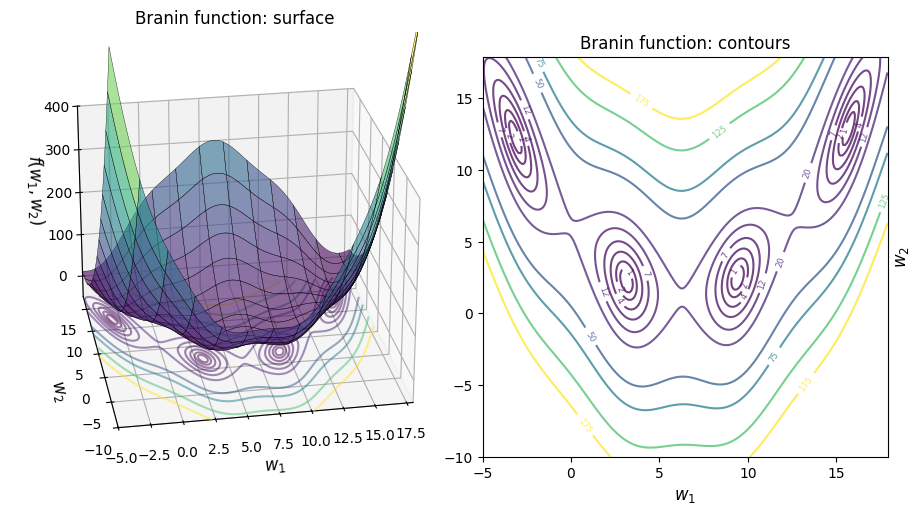

In [4]:
import matplotlib.pyplot as plt

# Visualize the Branin function in 3d
fig = plt.figure(figsize=(9, 5))

ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.set_position([0.025, 0.15, 0.5, 0.9])

ax.plot_surface(w1, w2, z, rstride=20, cstride=20, alpha=0.6, linewidth=0.25, edgecolors='k', cmap='viridis')
ax.view_init(elev=25.0, azim=-100.0)
ax.contour(w1, w2, z, zdir='z', levels=np.array([1, 2, 4, 7, 12, 20, 50, 75, 125, 175]),
           offset=-50, cmap='viridis', alpha=0.5)

ax.set_xlabel('$w_1$', fontsize=12)
ax.set_xlim(w1Min, w1Max)
ax.set_ylabel('$w_2$', fontsize=12)
ax.set_ylim(w2Min, w2Max)
ax.set_zlabel('$f(w_1, w_2)$', fontsize=12)
ax.set_zlim(-50, 400)
ax.set_zticks([0, 100, 200, 300, 400])
ax.dist = 9
ax.set_title('Branin function: surface', fontsize=12);

# Visualize the Branin function in 2d
ax = fig.add_subplot(1, 2, 2)
ax.set_position([0.55, 0.2, 0.45, 0.8])

ctr = ax.contour(w1, w2, z, levels=np.array([1, 2, 4, 7, 12, 20, 50, 75, 125, 175]), cmap='viridis', alpha=0.75)
ax.clabel(ctr, inline=1, fontsize=6)
ax.set_xlabel('$w_1$', fontsize=12)
ax.set_ylabel('$w_2$', fontsize=12)
ax.yaxis.set_label_position("right")
ax.set_title('Branin function: contours', fontsize=12);

# plt.savefig('./figures/CH05_F02_Kunapuli.png', format='png', dpi=300, bbox_inches='tight')
# plt.savefig('./figures/CH05_F02_Kunapuli.pdf', format='pdf', dpi=300, bbox_inches='tight')

**What the surface and contour plots show.** The 3D surface (left) reveals the bowl-like geometry of the Branin function: tall walls in the corners, deep valleys, and four "low spots" visible as concentric blue ellipses in the contour plot (right). Each ellipse marks a **local minimum**, and the gradient at any point inside an ellipse points outward toward the wall. The negative gradient therefore guides us inward, toward the basin's bottom.

**Strategic insight for ML.** Real loss landscapes -- a deep network's loss surface, for example -- are unimaginably more complex than this. But the *qualitative* behavior we will observe (descent into a basin, sensitivity to initialization, zig-zagging through narrow valleys) generalizes. The Branin function is a microscope: it lets us see clearly what is happening on the inside of every gradient-based learner.

### Implementing gradient descent

The pseudocode is short -- five steps per iteration:

```
initialize: w_old = some initial guess, converged = False
while not converged:
  1. compute the direction d = -gradient(w_old) / ||gradient(w_old)||  (unit-length descent direction)
  2. compute the step length alpha by line search
  3. update:  w_new = w_old + alpha * d
  4. if ||w_new - w_old|| < tolerance:  converged = True
  5. else:                               w_old = w_new
```

Two design choices deserve attention:

**Direction normalization.** We divide by $\|\nabla f\|$ so the *direction* is decoupled from its magnitude. The step length $\alpha$ alone controls how far we move. Without normalization, far-from-minimum points (huge gradients) would take giant steps and overshoot, while near-minimum points (tiny gradients) would barely move.

**Line search for $\alpha$.** We solve a 1D sub-problem: given the descent direction $\mathbf{d}$, find the scalar $\alpha > 0$ that minimizes $f(\mathbf{w}_{\text{old}} + \alpha \mathbf{d})$. `scipy.optimize.line_search` does this with Wolfe conditions. In machine learning the analogue is the **learning rate** $\eta$ -- but instead of an exact 1D optimization, $\eta$ is usually a fixed hyperparameter (or a schedule). We will see this connection again in Section 5.4 when tuning LightGBM's `learning_rate`.

In [5]:
from scipy.optimize import line_search

# Gradient descent with function f, and gradient g
def gradient_descent(f, g, x_init, max_iter=100, args=()):
    converged = False
    n_iter = 0

    x_old, x_new = np.array(x_init), None
    descent_path = np.full((max_iter + 1, 2), fill_value=np.nan)   # Save the descent path
    descent_path[n_iter] = x_old

    while not converged:
        n_iter += 1
        gradient = -g(x_old, *args)                                # Compute the negative gradient
        direction = gradient / np.linalg.norm(gradient)            # Normalize the gradient
        step = line_search(f, g, x_old, direction, args=args)      # Compute the step length using line search

        if step[0] is None:                     # If step length doesn't return a useful value, make it 1.0
            distance = 1.0
        else:
            distance = step[0]

        x_new = x_old + distance * direction                    # Compute the update
        descent_path[n_iter] = x_new

        # Update status
        # print('Iter {0:02d}: obj value = {1} (step={2}, dir={3}'.format(n_iter, step[3], step[0], direction))

        err = np.linalg.norm(x_new - x_old)                        # Compute amount of change between x_new and x_old
        if err <= 1e-3 or n_iter >= max_iter:                      # Check for convergence
            converged = True

        x_old = x_new                                              # Get ready for the next iteration

    return x_new, descent_path

We perform gradient descent on the Branin function, intializing our solution at $w = [-4, -5]$, and visualize our solution path.

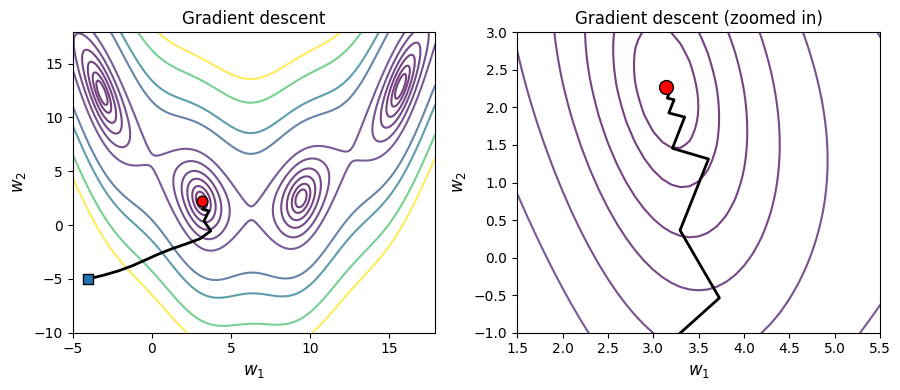

In [6]:
# Set the constants of the Branin function
a, b, c, r, s, t = 1, 5.1 / (4 * np.pi ** 2), 5 / np.pi, 6, 10, 1 / (8 * np.pi)

# Initialize and perform gradient descent
w_init = np.array([-4, -5])
w_optimal, w_path = gradient_descent(branin, branin_gradient, w_init, args=(a, b, c, r, s, t))

# Plot optimization path over all iterations
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
ax[0].contour(w1, w2, z, levels=np.array([1, 2, 4, 7, 12, 20, 50, 75, 125, 175]), cmap='viridis', alpha=0.75)
ax[0].plot(w_path[:, 0], w_path[:, 1], 'k', linewidth=2)
ax[0].scatter(w_init[0], w_init[1], s=60, marker='s', edgecolor='k', zorder=2)
ax[0].scatter(w_optimal[0], w_optimal[1], s=60, c='r', edgecolor='k', zorder=2)
ax[0].set_xlabel('$w_1$', fontsize=12)
ax[0].set_ylabel('$w_2$', fontsize=12)
ax[0].set_title('Gradient descent', fontsize=12)

# Plot optimization path zoomed in
ax[1].contour(w1, w2, z, levels=np.array([1, 2, 4, 7, 12, 20, 50, 75, 125, 175]), cmap='viridis', alpha=0.75)
ax[1].plot(w_path[:, 0], w_path[:, 1], 'k', linewidth=2)
ax[1].scatter(w_optimal[0], w_optimal[1], s=100, c='r', edgecolor='k', zorder=2)
ax[1].set_xlim(1.5, 5.5)
ax[1].set_ylim(-1, 3)
ax[1].set_xlabel('$w_1$', fontsize=12)
ax[1].set_ylabel('$w_2$', fontsize=12)
ax[1].set_title('Gradient descent (zoomed in)', fontsize=12)

fig.tight_layout()
# plt.savefig('./figures/CH05_F03_Kunapuli.png', format='png', dpi=300, bbox_inches='tight', pad_inches=0)
# plt.savefig('./figures/CH05_F03_Kunapuli.pdf', format='pdf', dpi=300, bbox_inches='tight', pad_inches=0)

**Reading the descent path.** Starting from the square at $\mathbf{w}_0 = [-4, -5]^T$, gradient descent traced a curved path (orange) into one of the four basins, terminating at the circle near $[-3.14, 12.27]^T$ -- one of the function's local minimizers. The zoomed view on the right exposes two characteristic behaviors of vanilla gradient descent:

1. **Step lengths shrink near the minimum.** As we approach the basin, $\|\nabla f\|$ shrinks toward zero (gradients vanish at minimizers), so each step is shorter than the last. Convergence is *asymptotic*: the algorithm halts when consecutive steps fall below the tolerance ($10^{-3}$ here), not because the gradient is exactly zero.

2. **Zig-zagging.** Inside narrow valleys, the gradient points perpendicular to the valley's *long* axis -- across the walls, not along the floor. Each step bounces off the opposite wall, producing the characteristic crisscross pattern. This is why methods like **momentum** and **Adam** dominate in deep learning: they accumulate gradient history to smooth out the zig-zag and accelerate motion along the valley.

**Cross-chapter connection.** When we implement gradient *boosting* in Section 5.2, each boosting iteration is structurally identical to a gradient descent step -- we will pick a direction (a regression tree), a step length (line search), and update the ensemble. The same dynamics shown here will reappear inside our boosting loop.

### Sensitivity to initialization

Starting from a different point can drag gradient descent into a *different* basin. Below we run the optimizer from 100 random initializations sampled to cover all four sides of the contour map, and overlay every descent path.

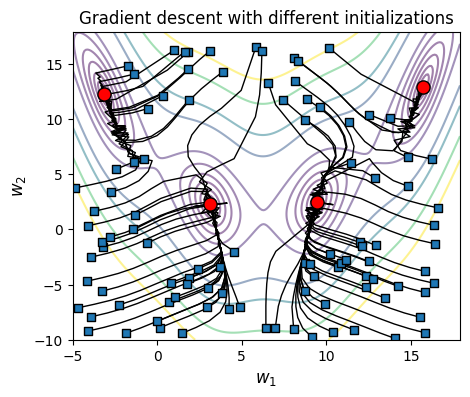

In [7]:
n = 25
inits = np.r_[np.c_[np.random.uniform(-5, 1, n), np.random.uniform(-10, 7, n)],
              np.c_[np.random.uniform(1, 11, n), np.random.uniform(-10, -1, n)],
              np.c_[np.random.uniform(11, 17, n), np.random.uniform(-10, 7, n)],
              np.c_[np.random.uniform(-2, 14, n), np.random.uniform(9, 17, n)]
             ]


plt.figure(figsize=(5, 4))
plt.contour(w1, w2, z, levels=np.array([1, 2, 4, 7, 12, 20, 50, 75, 125, 175]), cmap='viridis', alpha=0.5)

minima = []
# For each initialization, optimize and plot the path
for i, w_init in enumerate(inits):
    w, path = gradient_descent(branin, branin_gradient, w_init, args=(a, b, c, r, s, t))
    plt.plot(path[:, 0], path[:, 1], 'k', linewidth=1)
    minima.append(w)

minima = np.array(minima)
from sklearn.cluster import KMeans
opt = KMeans(n_clusters=4).fit(minima)
minima = opt.cluster_centers_

plt.scatter(inits[:, 0], inits[:, 1], s=30, marker='s', edgecolor='k', zorder=2)
plt.scatter(minima[:, 0], minima[:, 1], c='r', s=90, marker='o', edgecolor='k', zorder=2)
plt.xlabel('$w_1$', fontsize=12)
plt.ylabel('$w_2$', fontsize=12)
plt.title('Gradient descent with different initializations', fontsize=12);

fig.tight_layout()
# plt.savefig('./figures/CH05_F04_Kunapuli.png', format='png', dpi=300, bbox_inches='tight', pad_inches=0)
# plt.savefig('./figures/CH05_F04_Kunapuli.pdf', format='pdf', dpi=300, bbox_inches='tight', pad_inches=0)

**Each color represents the basin the run converged into.** Of the four global minima the Branin function admits, every initial guess pulled the optimizer into the *closest* one. Crucially, initial points that started near a "ridge" between two basins ended up in qualitatively very different solutions despite being arbitrarily close to each other.

**The ML implication is sharp.** Non-convex training objectives -- including those of neural networks, $k$-means, and gaussian-mixture models -- have many local minima. The minimum gradient descent finds depends on **where you start**. Three takeaways:

- **Random restarts** (running training from many initializations and keeping the best) are a brute-force defense against bad local minima.
- **Pretraining** (initializing from a model trained on a related task) is a smarter version of the same idea, ubiquitous in modern deep learning.
- **Convexity is a gift.** When the loss is convex (e.g., logistic regression with $\ell_2$ regularization, linear SVMs, ridge regression), every local minimum *is* the global minimum and any reasonable initialization works. The Branin function is non-convex; the squared-loss problem we tackle next is convex -- compare the two.

---
## 5.1.2 Gradient Descent over a Loss Function: Training a Linear Classifier

We now move from a contrived 2D test function to the **actual** use case: minimizing a loss function over training data to learn a model. We build a small linearly-separable 2D classification problem and train a linear classifier with gradient descent on the squared loss.

This is the simplest possible end-to-end gradient-based training pipeline -- and it contains every conceptual ingredient that will reappear in gradient boosting.

In [8]:
import matplotlib.cm as cm
import matplotlib.colors as col
import numpy as np

# Plot a 2D classification data set onto the specified axes
def plot_2d_data(ax, X, y, s=20, alpha=0.95, xlabel=None, ylabel=None, title=None, legend=None, colormap='viridis'):
    # Get data set size
    n_examples, n_features = X.shape

    # Check that the data set is 2D
    if n_features != 2:
        raise ValueError('Data set is not 2D!')

    # Check that the lengths of X and y match
    if n_examples != len(y):
        raise ValueError('Length of X is not equal to the length of y!')

    # Get the unique labels and set up marker styles and colors
    unique_labels = np.sort(np.unique(y))
    n_classes = len(unique_labels)

    markers = ['o', 's', '^', 'v', '<', '>', 'p']

    cmap = cm.get_cmap(colormap)
    colors = cmap(np.linspace(0, 0.5, num=n_classes))

    # Set marker sizes
    if isinstance(s, np.ndarray):
        # If its an ndarray, make sure it has the same size as the number of examples
        if len(s) != n_examples:
            raise ValueError('Length of s is not equal to the length of y!')
    else:
        # Otherwise, make it an nd_array
        s = np.full_like(y, fill_value=s)

    # Plot the data
    for i, label in enumerate(unique_labels):
        marker_color = col.rgb2hex(colors[i])
        marker_shape = markers[i % len(markers)]
        ax.scatter(X[y == label, 0], X[y == label, 1], s=s[y == label],
                   marker=marker_shape,
                   c=marker_color,
                   edgecolors='k', alpha=0.5)

    # Add labels, title and bounds
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=12)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=12)
    if title is not None:
        ax.set_title(title)

    # Set the legend
    if legend is not None:
        ax.legend(legend, fontsize=12);

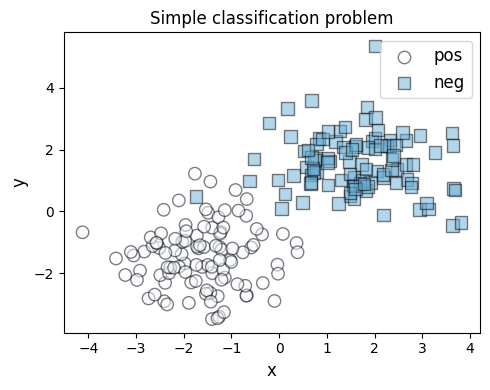

In [9]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=200, n_features=2,
                  centers=[[-1.5, -1.5], [1.5, 1.5]], random_state=42)


fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 4))
plot_2d_data(ax, X, y, xlabel='x', ylabel='y', s=80, alpha=0.3,
             title='Simple classification problem',
             legend=['pos', 'neg'], colormap='Blues')

fig.tight_layout()
# plt.savefig('./figures/CH05_F05_Kunapuli.png', format='png', dpi=300, bbox_inches='tight', pad_inches=0)
# plt.savefig('./figures/CH05_F05_Kunapuli.pdf', format='pdf', dpi=300, bbox_inches='tight', pad_inches=0)

**The dataset.** We generated $n = 200$ points in $\mathbb{R}^2$ from two Gaussian blobs centered at $(-1.5, -1.5)$ (label $y = 0$) and $(1.5, 1.5)$ (label $y = 1$). The clusters are well-separated but overlap slightly near the origin -- realistic enough that an exact zero-error fit is impossible, easy enough that any reasonable linear classifier should top 95%.

**Why a linear, no-bias model.** The classifier we will fit is

$$h_{\mathbf{w}}(\mathbf{x}) = w_1 x_1 + w_2 x_2$$

with $\mathbf{w} = [w_1, w_2]^T \in \mathbb{R}^2$. No bias term, no nonlinearity. This keeps the parameter space 2-dimensional -- exactly matching the visualization we used for the Branin function. The decision boundary is the line $\mathbf{w}^T \mathbf{x} = 0$, which always passes through the origin. Because we centered both classes symmetrically around the origin, this constraint is harmless here.

Now, let's say that we want to learn a linear classifier $h(\mathbf{x})$ of the form shown below:

\\[
h_\mathbf{w}(\mathbf{x}) = w_1 x_1 + w_2 x_2,
\\]

which takes a training example $\mathbf{x} = [x_1, x_2]^T$. The classifier is parameterized by $\mathbf{w} = [w_1, w_2]^T$, which we have to learn using the training examples. In order to train a classifier, we'll need a loss function.

For this problem, we will chose the **squared loss** of the classifier $h_\mathbf{w}(\mathbf{x})$ over the training set of $n$ training examples $\mathbf{x}_i = [x_1^i, x_2^i]^T$, $i=1, ..., n$, with corresponding labels $y_i$.

\\[
f_{loss}(w_1, w_2) = \frac{1}{2} \sum_{i=1}^n \left( y_i - h_\mathbf{w}(\mathbf{x}_i) \right)^2 = \frac{1}{2} \sum_{i=1}^n \left( y_i - w_1 x_1^i - w_2 x_2^i \right)^2 = \frac{1}{2} (\mathbf{y} - X\mathbf{w})^T (\mathbf{y} - X\mathbf{w}).
\\]

Similar to the Branin function in Section 5.2.1, we can compute the gradient of this loss function with respect to $w_1$ and $w_2$.

\\[
g(w_1, w_2) = \left[ \begin{array}{c}
    \frac{\partial f_{loss}(w_1, w_2)}{\partial w_1} \\
    \frac{\partial f_{loss}(w_1, w_2)}{\partial w_2}
    \end{array} \right]
    = \left[ \begin{array}{c}
    - \sum_{i=1}^n \left( y_i - w_1 x_1 - w_2 x_2 \right) x_1\\
    - \sum_{i=1}^n \left( y_i - w_1 x_1 - w_2 x_2 \right) x_2 \end{array} \right]
    = -X^T (\mathbf{y} - X\mathbf{w})
\\]

In both the equations above, the expressions on the far right are the vectorized versions of the loss function, where $X$ is the data matrix and $\mathbf{y}$ is the label vector. The vectorized version is more compact and easier and more efficient to implement as it avoids explicit loops for summation.

**Vectorized form.** For $n$ training examples stacked into a matrix $\mathbf{X} \in \mathbb{R}^{n \times 2}$ and labels $\mathbf{y} \in \{0,1\}^n$, the total squared loss is

$$L(\mathbf{w}) = \tfrac{1}{2}\,\|\mathbf{y} - \mathbf{X}\mathbf{w}\|_2^2 = \tfrac{1}{2}\,(\mathbf{y} - \mathbf{X}\mathbf{w})^T (\mathbf{y} - \mathbf{X}\mathbf{w})$$

with gradient

$$\nabla L(\mathbf{w}) = -\mathbf{X}^T (\mathbf{y} - \mathbf{X}\mathbf{w})$$

**Why squared loss for a *classification* problem?** Squared loss is standard for regression but mathematically convenient here: the loss is convex in $\mathbf{w}$, the gradient is a clean linear-algebra expression, and the geometry is a perfect bowl with one global minimum. Production classification systems prefer **cross-entropy** (logistic loss) for its better gradient behavior near the decision boundary -- we will see exactly this loss in Section 5.4 when training LightGBM, and it is also the default for `LogisticRegression` in scikit-learn. For now, squared loss keeps the math transparent.

In [10]:
def squared_loss(w, X, y):
    return 0.5 * np.sum((y - np.dot(X, w))**2)


def squared_loss_gradient(w, X, y):
    return -np.dot(X.T, (y - np.dot(X, w)))

**Two helper functions, both vectorized.** `squared_loss(w, X, y)` computes $\tfrac{1}{2}\sum_i (y_i - \mathbf{x}_i^T \mathbf{w})^2$ via a single dot product `np.dot(X, w)`, avoiding any Python-level loop over $n = 200$ training examples. The gradient `squared_loss_gradient` does the same -- one matrix-vector multiply yields all 2 partial derivatives at once. **For large datasets this matters enormously**: a vectorized implementation is typically $50$ to $200\times$ faster than the equivalent for-loop version, because NumPy dispatches to BLAS routines that exploit SIMD instructions and CPU caches. This is the same trick that lets PyTorch/TensorFlow compute gradients on millions of parameters in milliseconds.

As before, we visualize the function we want to optimize.

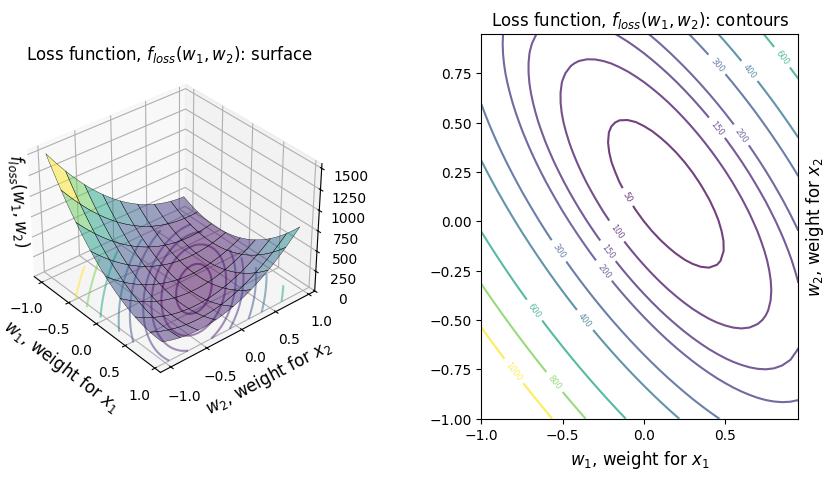

In [11]:
# %matplotlib inline

fig = plt.figure(figsize=(9, 5))

# Plot the loss function
w1Min, w1Max, w2Min, w2Max = -1, 1, -1, 1
w1, w2 = np.meshgrid(np.arange(w1Min, w1Max, 0.05),
                     np.arange(w2Min, w2Max, 0.05))
z = np.apply_along_axis(squared_loss, 1, np.c_[w1.ravel(), w2.ravel()], X, y)
z = z.reshape(w1.shape)

ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.plot_surface(w1, w2, z, rstride=5, cstride=5, alpha=0.5, linewidth=0.25, edgecolors='k', cmap='viridis')
ax.view_init(elev=34, azim=-40.0)
ax.contour(w1, w2, z, zdir='z', levels=np.array([50, 100, 150, 200, 300, 400, 600, 800, 1000]),
           offset=-50, cmap='viridis', alpha=0.5)
ax.set_xlabel('$w_1$, weight for $x_1$', fontsize=12)
ax.set_ylabel('$w_2$, weight for $x_2$', fontsize=12)
# ax.set_zlabel('$L(w)$ ', fontsize=12)
ax.text(-1.3, -1.4, 450, '$f_{loss}(w_1, w_2)$', (0, 0, 1), fontsize=12)

ax.dist = 8
ax.set_title('Loss function, $f_{loss}(w_1, w_2)$: surface', fontsize=12)
# pos1 = ax.get_position() # get the original position
# pos2 = [pos1.x0 - 0.1, pos1.y0,  pos1.width, pos1.height]
# ax.set_position(pos2) # set a new position

# Plot the contour
ax = fig.add_subplot(1, 2, 2)
ctr = ax.contour(w1, w2, z, levels=np.array([50, 100, 150, 200, 300, 400, 600, 800, 1000]),
                 cmap='viridis', alpha=0.75)
ax.clabel(ctr, inline=1, fontsize=6)
ax.set_xlabel('$w_1$, weight for $x_1$', fontsize=12)
ax.set_ylabel('$w_2$, weight for $x_2$', fontsize=12)
ax.set_title('Loss function, $f_{loss}(w_1, w_2)$: contours', fontsize=12)
ax.yaxis.set_label_position("right")
pos1 = ax.get_position() # get the original position
pos2 = [pos1.x0 + 0.1, pos1.y0, pos1.width, pos1.height]
ax.set_position(pos2) # set a new position


# fig.tight_layout()
# plt.savefig('./figures/CH05_F06_Kunapuli.png', format='png', dpi=300, bbox_inches='tight', pad_inches=0)
# plt.savefig('./figures/CH05_F06_Kunapuli.pdf', format='pdf', dpi=300, bbox_inches='tight', pad_inches=0)

**A single bowl, one minimum.** Both views of the squared-loss surface confirm what the math promised: the loss is **convex** in $\mathbf{w}$. There is exactly one local minimum, and it is the global minimum. Compare this to the four-basin Branin landscape -- starting from any reasonable $\mathbf{w}_0$, gradient descent will glide straight to the unique optimum.

**Why this matters.** Convex optimization is the easy case. Whenever your loss is convex (linear regression, ridge regression, logistic regression, linear SVMs), you sleep well at night knowing your training procedure converges to a unique solution -- no random restarts, no initialization heuristics. As soon as you add hidden layers (neural networks), tree splits (gradient boosting iterations), or non-convex regularizers, you lose this guarantee and must manage local minima carefully.

As before, we perform gradient descent, this time initializing at $\mathbf{w} = [0.0, -0.99]$.

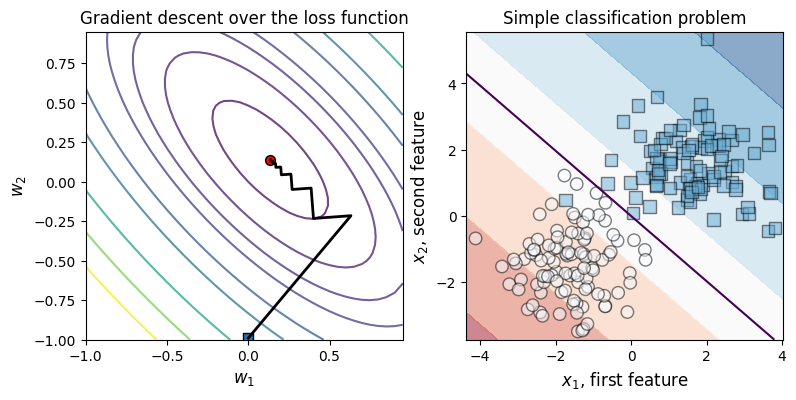

In [12]:
%matplotlib inline

w_init = np.array([0.0, -0.99])
w, path = gradient_descent(squared_loss, squared_loss_gradient, w_init, args=(X, y))

# Compute the Loss function in this domain
w1Min, w1Max, w2Min, w2Max = -1, 1, -1, 1
w1, w2 = np.meshgrid(np.arange(w1Min, w1Max, 0.05),
                     np.arange(w2Min, w2Max, 0.05))
z = np.apply_along_axis(squared_loss, 1, np.c_[w1.ravel(), w2.ravel()], X, y)
z = z.reshape(w1.shape)

# Plot optimization path over all iterations
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
ax[0].contour(w1, w2, z, levels=np.array([25, 50, 100, 150, 200, 300, 400, 600, 800, 1000]),
              cmap='viridis', alpha=0.75)
ax[0].scatter(w_init[0], w_init[1], s=60, marker='s', zorder=2, edgecolor='k')
ax[0].scatter(w[0], w[1], c='r', s=50, zorder=2, edgecolor='k')
ax[0].plot(path[:, 0], path[:, 1], 'k', linewidth=2)
ax[0].set_xlabel('$w_1$', fontsize=12)
ax[0].set_ylabel('$w_2$', fontsize=12)
ax[0].set_title('Gradient descent over the loss function', fontsize=12)

# Plot the solution
xMin, xMax = X[:, 0].min() - 0.25, X[:, 0].max() + 0.25
yMin, yMax = X[:, 1].min() - 0.25, X[:, 1].max() + 0.25
xMesh, yMesh = np.meshgrid(np.arange(xMin, xMax, 0.05),
                           np.arange(yMin, yMax, 0.05))
zMesh = np.dot(np.c_[xMesh.ravel(), yMesh.ravel()], w)
zMesh = (zMesh.reshape(xMesh.shape) + 1) / 2
ax[1].contourf(xMesh, yMesh, zMesh, cmap='RdBu', alpha=0.5)
ax[1].contour(xMesh, yMesh, zMesh, levels=[0.5])
plot_2d_data(ax[1], X, y, colormap='Blues', s=80, alpha=0.4)
ax[1].set_xlabel('$x_1$, first feature', fontsize=12)
ax[1].set_ylabel('$x_2$, second feature', fontsize=12)
ax[1].set_title('Simple classification problem', fontsize=12);

# fig.tight_layout()
# plt.savefig('./figures/CH05_F07_Kunapuli.png', format='png', dpi=300, bbox_inches='tight', pad_inches=0)
# plt.savefig('./figures/CH05_F07_Kunapuli.pdf', format='pdf', dpi=300, bbox_inches='tight', pad_inches=0)

**The descent path.** Starting from the square at $\mathbf{w}_0 = [0.0, -0.99]^T$ -- bottom of the parameter space -- gradient descent climbed up and slightly to the right until it found the bowl's bottom (circle). The path on the loss surface (left) shows the same shrinking-step asymptotic behavior we saw with Branin, but **without** zig-zagging: the bowl is symmetric, so the gradient always points roughly toward the minimum. Convexity in action.

The right plot shows the *learned model* in feature space: the line $\mathbf{w}^T \mathbf{x} = 0$ separates the two clusters cleanly. Visually, the boundary slopes positive, consistent with the cluster centers $(\pm 1.5, \pm 1.5)$ lying on a 45° line.

In [13]:
print(w)

[0.13643511 0.13862275]


**The learned weights.** Gradient descent converged to

$$\mathbf{w}^* \approx [0.1364,\ 0.1386]^T$$

The two components are nearly equal -- exactly what we should expect, because the cluster centers lie symmetrically on the line $x_1 = x_2$. The classifier's decision rule reduces to $0.1364\,x_1 + 0.1386\,x_2 \geq 0$, equivalent to $x_1 + x_2 \gtrsim 0$, i.e., the perpendicular bisector of the segment from $(-1.5, -1.5)$ to $(1.5, 1.5)$. **The optimum is geometric:** it depends on the data's structure, not on training noise.

**A note on absolute magnitudes.** The weights $\approx 0.14$ are small but the *direction* of $\mathbf{w}$ is what matters for classification (the sign of $\mathbf{w}^T \mathbf{x}$). Squared loss does not enforce $\|\mathbf{w}\| = 1$; gradient descent on this loss naturally shrinks the magnitude to balance the squared error contribution from positive and negative examples. If you wanted unit-norm weights you would add an explicit constraint or use a different loss.

The final $\mathbf{w}$ is trained by performing gradient descent on the loss function defined over the training examples. From the figure on the right above, we can see that gradient descent does, in fact, produce a nice fit.

In [14]:
ypred = (np.dot(X, w) >= 0).astype(int)
from sklearn.metrics import accuracy_score
accuracy_score(y, ypred)

0.995

**Training accuracy: 99.5%** -- 199 out of 200 examples classified correctly. The single misclassification is one point that overlaps slightly with the opposite cluster (visible in the original scatter plot near the boundary).

**Sanity-checking the result.** A linear separator achieving 99.5% on a *nearly* linearly separable dataset is the expected outcome. If we saw 60-70%, something would be wrong: a bug in the gradient, a too-tight tolerance causing premature termination, or a learning-rate issue. **Always check accuracy after training.** It is the cheapest diagnostic available.

**Putting it all together.** We just trained a model from scratch using:
1. A model class (linear classifier $h_{\mathbf{w}}$) with parameters $\mathbf{w} \in \mathbb{R}^2$.
2. A loss function (squared loss) that scores how badly each candidate $\mathbf{w}$ fits the data.
3. An optimization algorithm (gradient descent with line search) that finds the minimum-loss $\mathbf{w}$.

This three-part recipe -- **model + loss + optimizer** -- is the universal template for supervised learning. Sections 5.2--5.5 show that **gradient boosting** is the same recipe at one level higher: instead of optimizing over a parameter vector $\mathbf{w}$, we optimize over a *function* $F$ -- treating each weak regressor we add as a "step" in function space. The math is the same; only the domain changes.

---

> ### Checkpoint — End of Section 5.1
>
> You should now be able to explain, in your own words:
>
> 1. **Why we follow the negative gradient.** The gradient $\nabla f$ points in the direction of steepest *ascent*; we negate it to descend.
> 2. **What "line search" buys us.** It picks the optimal step length $\alpha$ in the chosen descent direction, preventing both overshooting and slow progress.
> 3. **Why initialization matters for non-convex problems.** Different starting points fall into different basins. The Branin function had four basins; a random initialization picked which one we found.
> 4. **Why convex problems are the easy case.** The squared-loss surface for our linear classifier was a single bowl, so any reasonable initialization led to the same optimum.
>
> ### Your turn (~30 seconds)
>
> In the gradient-descent code, change `w_init` for the Branin example from `[-4, -5]` to `[10, 10]`. Re-run the cell. Which of the four basins does the optimizer fall into now? Try `[5, 0]` -- is the answer obvious from the contour plot?

**Now we have everything we need to build a gradient booster from scratch.**

---

# Section 5.2 — Gradient Boosting: From Scratch, Then with Scikit-Learn

> **What you will be able to do after this section.**
>
> 1. Derive the magic equation: **residual = negative gradient of squared loss**, and explain why this means each boosting iteration is a gradient-descent step in function space.
> 2. Implement gradient boosting from scratch and watch it solve a non-linearly-separable problem (two moons).
> 3. Use `GradientBoostingClassifier` and `HistGradientBoostingClassifier` from scikit-learn, and explain why the histogram variant is the speed-killer feature on large data.

## The conceptual leap

In Section 5.1 we minimized a loss function with respect to a *parameter vector* $\mathbf{w}$. Now we will minimize a loss with respect to the *predictions themselves* -- treating each $f_i = f(\mathbf{x}_i)$ as a free variable. This shift is what unlocks boosting.

**The single most important equation in this chapter:**

$$\underbrace{-\nabla_{f_i} \tfrac{1}{2}(y_i - f_i)^2}_{\text{negative gradient}}
\;=\;
\underbrace{y_i - f_i}_{\text{residual}}$$

Both sides equal "the gap between truth and current prediction." So if we train a regressor to predict residuals, we are -- quite literally -- training a regressor to approximate the negative gradient. Add it to the ensemble, scaled by a step length, and we have just performed *gradient descent in the space of all possible models*. Repeat until satisfied. **That's gradient boosting.**

In [15]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=200, noise=0.15, random_state=13)
y = 2 * y - 1

**Why $y \mapsto 2y - 1$?** `make_moons` returns labels in $\{0, 1\}$, but in this section we work with $\{-1, +1\}$ labels. The transformation $2y - 1$ maps $0 \mapsto -1$ and $1 \mapsto +1$ exactly. **Why bother?** With $\pm 1$ labels, the *sign* of a real-valued prediction directly gives the class -- no thresholding at $0.5$, no calibration. The residual $y - f$ is also automatically in $[-2, +2]$, symmetric around zero, which makes the regressor's job (predicting the residual) cleaner.

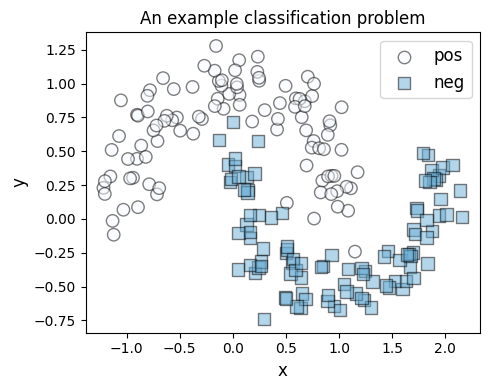

In [16]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 4))
plot_2d_data(ax, X, y, xlabel='x', ylabel='y', s=80, alpha=0.3,
             title='An example classification problem',
             legend=['pos', 'neg'], colormap='Blues')
fig.tight_layout()

**The two-moons dataset.** This is a classic non-linearly-separable problem: two interleaved crescents with $n = 200$ points and Gaussian noise (`noise=0.15`). A single linear separator cannot achieve much better than $\sim 75\%$ accuracy here -- the data demands a non-linear classifier. Gradient boosting will build that non-linearity by *summing* axis-aligned decision stumps; each stump is linear (a single threshold split), but their sum can carve out arbitrarily complex regions.

### From squared loss to residuals -- the key derivation

Total squared loss across $n$ training examples:

$$L(\mathbf{f}) = \tfrac{1}{2}\sum_{i=1}^{n} (y_i - f_i)^2$$

This is a function of the **prediction vector** $\mathbf{f} = [f_1, \ldots, f_n]^T$ -- not a function of model parameters. Its gradient with respect to $f_i$ is exactly

$$g_i = \frac{\partial L}{\partial f_i} = -(y_i - f_i) = -r_i$$

where $r_i = y_i - f_i$ is the **residual** for example $i$.

**The chain of equalities to remember:**
$$\boxed{\;-\,\text{gradient}_i \;=\; r_i \;=\; y_i - f_i\;}$$

Gradient boosting treats these residuals as **regression targets** for a new weak learner. At each iteration $t$, we fit a regression tree $h_t(\mathbf{x})$ to predict $r_i$ from $\mathbf{x}_i$, then add $\alpha_t \cdot h_t$ to the running ensemble. The result: even though our base learner is a *regressor*, we end up with a strong *classifier* -- because the regressor learns to push the ensemble's predictions toward the true labels.

In [17]:
import numpy as np
f = np.full((len(y), ), fill_value=0.0)
residuals = -(y - f)

**Iteration 1 setup.** We initialize predictions to $F = \mathbf{0}$ (a constant zero model -- maximally uninformative). The first residuals are simply the labels themselves: $r_i = y_i - 0 = y_i$.

So at iteration 1:
- For positive examples ($y_i = +1$): residual is $+1$ -- "the model needs to predict more positive here."
- For negative examples ($y_i = -1$): residual is $-1$ -- "the model needs to predict more negative here."

**The base regressor's job:** find a function $h_1(\mathbf{x})$ that approximates these residuals. A successful $h_1$ will output values close to $+1$ in regions of feature space dominated by positive examples and close to $-1$ in regions dominated by negative examples. **That is exactly the shape of a useful classifier.**

For positive examples, we have that the **negative** residual $r_i = y_i - f(\mathbf{x}_i) = 1 - 0 = +1$. This residual suggests that the classification of the positive examples can be improved by pushing the model by towards $1$. For negative examples, $r_i = y_i - f(\mathbf{x}_i) = -1 - 0 = -1$, which suggests that the classification of the negative examples can be improved by pushing the model by away from $1$ and towards $-1$.

The residual ($r_i$) is a measure of how badly a particular training example is misclassified. This is similar to the weight ($D_i$) of training examples in AdaBoost, which also represented how badly a training example was misclassified.

Again, similar to AdaBoost, we will train a weak learner. In AdaBoost, we used weighted training examples $(\mathbf{x}_i, y_i, D_i)$ to train a weak classifier. In gradient boosting, we will use training examples and residuals $(\mathbf{x}_i, r_i)$ to train a **weak regressor**.

In [18]:
from sklearn.tree import DecisionTreeRegressor
h = DecisionTreeRegressor(max_depth=1)
h.fit(X, -residuals)  # Observe the negated residuals: we want to approximate the negative gradient

DecisionTreeRegressor(max_depth=1)

**Fitting the first weak regressor.** We use a `DecisionTreeRegressor(max_depth=1)` -- a **decision stump** with a single split. The tree learner finds the threshold along one feature that best partitions the residuals into two groups (minimizing within-group variance). At iteration 1, with all residuals at $\pm 1$, the best stump effectively asks "which feature value best separates positive from negative examples?"

**Why depth 1?** Shallow trees are deliberately weak: they have high bias but low variance. The boosting *ensemble* compensates by adding many of them sequentially, each correcting the previous mistakes. This bias-variance trade-off is the central design choice in gradient boosting -- shallow trees + many iterations is the prototypical recipe.

**The `-residuals` argument.** The regressor is fit on `X, -residuals`. Why the negative sign? Because what we want to approximate is the *negative* gradient (the descent direction), and we already established that residual $r_i = -\text{gradient}_i$. So `-residuals` $= +\text{gradient}_i$, and `h.predict(X)` will output a function approximating the gradient. The line search step (next) then moves us along that direction. **Many implementations fold the sign into the line-search step instead** -- equivalent math, different bookkeeping.

### Visualizing the first three boosting iterations

The cell below runs the first three iterations of gradient boosting *manually* and plots three panels per iteration:

1. **Residuals** as a colored scatter on the data -- showing which examples need correction.
2. **The newly fit regressor** $h_t$'s predictions on the data.
3. **The cumulative ensemble** $F = F + \alpha_t h_t$ after this iteration.

Watch how the ensemble progressively carves out the moon shapes.

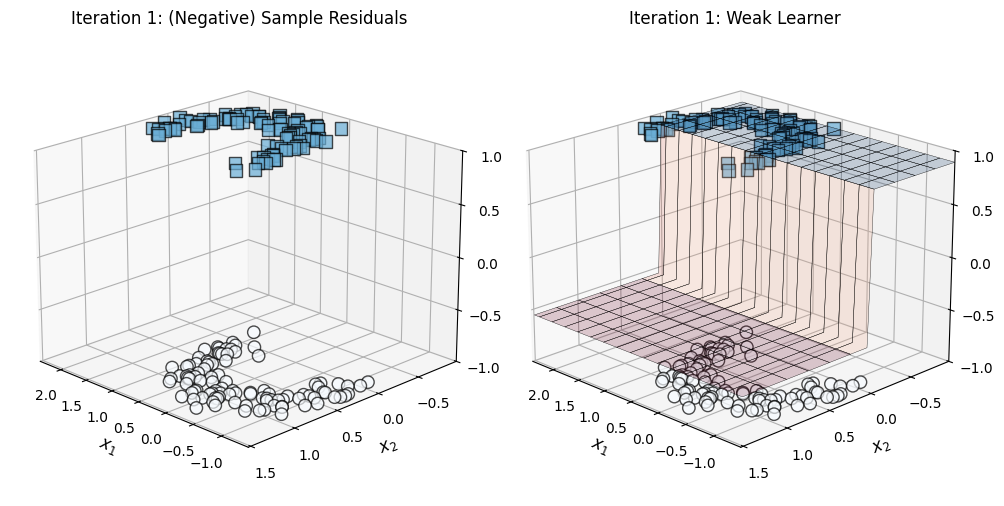

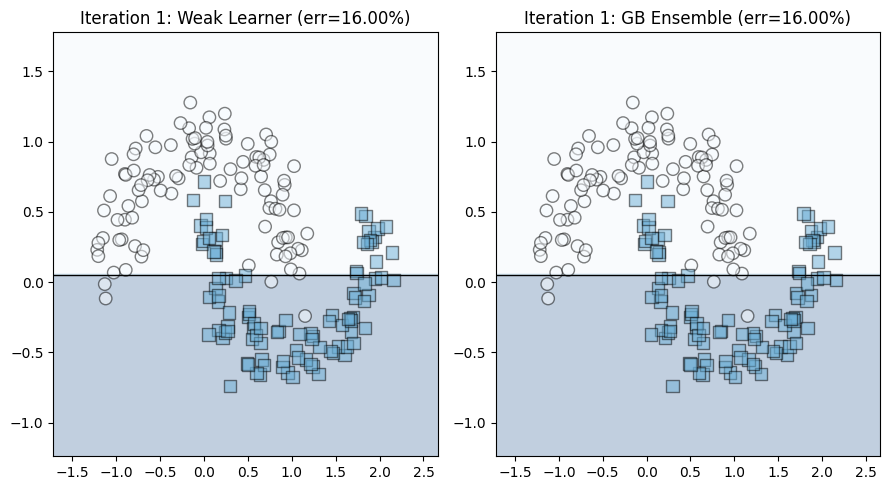

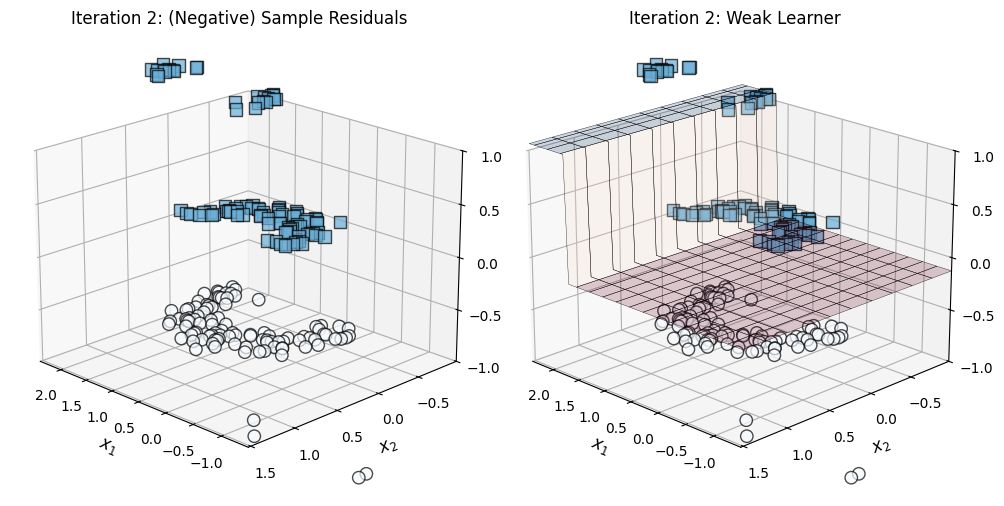

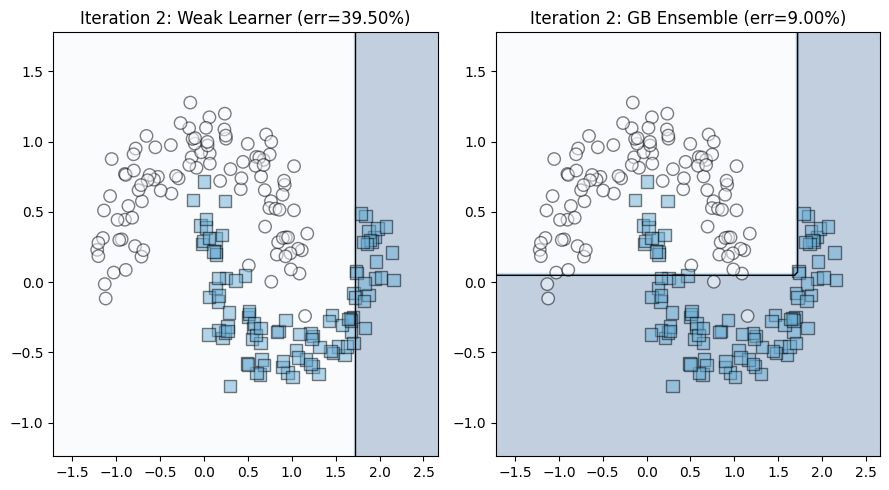

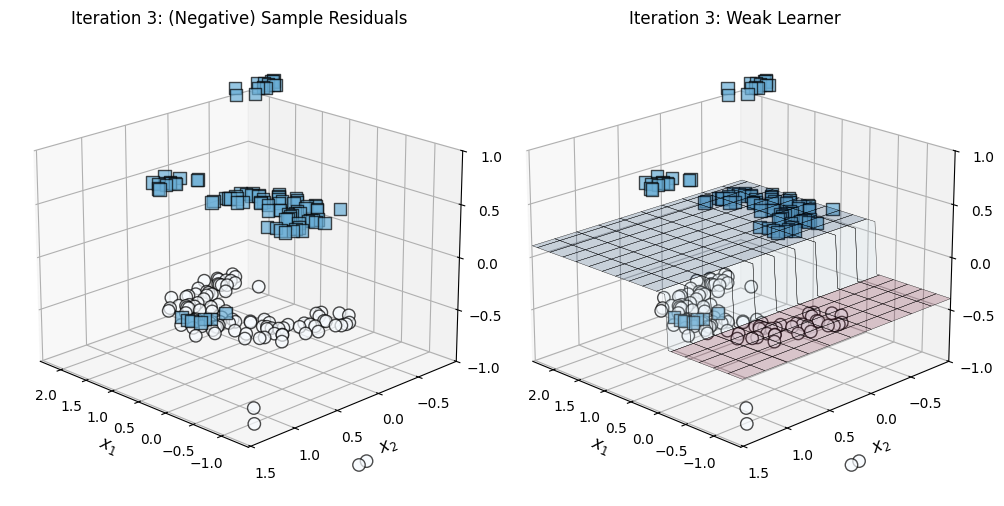

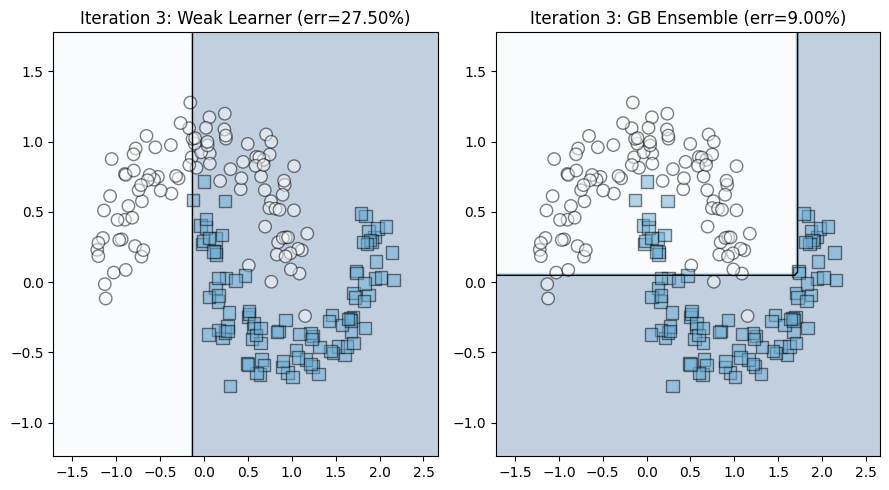

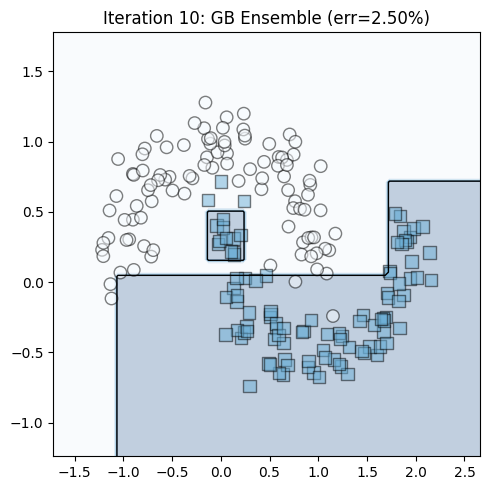

In [19]:
from scipy.optimize import minimize_scalar
from sklearn.metrics import accuracy_score
import matplotlib.cm as cm
import matplotlib.colors as col

# Set up a mesh for 3d plotting
xMin, xMax = X[:, 0].min() - 0.25, X[:, 0].max() + 0.25
yMin, yMax = X[:, 1].min() - 0.25, X[:, 1].max() + 0.25
xMesh, yMesh = np.meshgrid(np.arange(xMin, xMax, 0.05),
                           np.arange(yMin, yMax, 0.05))

cmap = cm.get_cmap('Blues')
colors = cmap(np.linspace(0, 0.5, num=2))
# views = [(36, 118), (48, -116), (11, 108)]
views = [(20, 135), (20, 135), (20, 135)]


# Initialize
n_samples, n_features = X.shape
n_estimators = 10
ensemble = []
F = np.full((n_samples, ), 0.0)  # Predictions of each training example using the ensemble

for t in range(n_estimators):
    # Fit a weak learner to the residuals, which are computed as gradient(Loss(y, F))
    residuals = y - F
    h = DecisionTreeRegressor(max_depth=1)
    h.fit(X, residuals)

    # ----------------------------------------------
    # Visualize the residuals and their fit in 3d
    if t in [0, 1, 2]:
        fig = plt.figure(figsize=(10, 5))

        ax = fig.add_subplot(1, 2, 1, projection='3d')
        ax.view_init(elev=views[t][0], azim=views[t][1])
        ax.scatter(X[y<0, 0], X[y<0, 1], residuals[y<0], c=col.rgb2hex(colors[0]),
                   marker='o', s=80, edgecolors='k', alpha=0.7)
        ax.scatter(X[y>0, 0], X[y>0, 1], residuals[y>0], c=col.rgb2hex(colors[1]),
                   marker='s', s=80, edgecolors='k', alpha=0.7)
        ax.set_xlabel('$x_1$', fontsize=12)
        ax.set_xlim(xMin, xMax)
        ax.set_ylabel('$x_2$', fontsize=12)
        ax.set_ylim(yMin, yMax)
        # ax.set_zlabel('Negative Residuals')
        ax.set_zlim(-1, 1)
        ax.set_zticks([-1., -0.5, 0.0, 0.5, 1.])
        ax.set_title('Iteration {0}: (Negative) Sample Residuals '.format(t + 1), fontsize=12)

        ax = fig.add_subplot(1, 2, 2, projection='3d')
        zMesh = h.predict(np.c_[xMesh.ravel(), yMesh.ravel()])
        zMesh = zMesh.reshape(xMesh.shape)
        ax.plot_surface(xMesh, yMesh, zMesh, rstride=5, cstride=5,
                        alpha=0.2, linewidth=0.25, edgecolors='k', cmap='RdBu')
        ax.view_init(elev=views[t][0], azim=views[t][1])
        ax.scatter(X[y<0, 0], X[y<0, 1], residuals[y<0], c=col.rgb2hex(colors[0]),
                   marker='o', s=80, alpha=0.7, edgecolors='k')
        ax.scatter(X[y>0, 0], X[y>0, 1], residuals[y>0], c=col.rgb2hex(colors[1]),
                   marker='s', s=80, alpha=0.7, edgecolors='k')
        ax.set_xlabel('$x_1$', fontsize=12)
        ax.set_xlim(xMin, xMax)
        ax.set_ylabel('$x_2$', fontsize=12)
        ax.set_ylim(yMin, yMax)
        # ax.set_zlabel('Negative Residuals')
        ax.set_zlim(-1, 1)
        ax.set_zticks([-1., -0.5, 0.0, 0.5, 1.])
        ax.set_title('Iteration {0}: Weak Learner'.format(t + 1), fontsize=12)


        fig.tight_layout()
#         plt.savefig('./figures/CH05_F{0:2d}_Kunapuli.png'.format(2*t + 11), format='png',
#                     dpi=300, bbox_inches='tight')
#         plt.savefig('./figures/CH05_F{0:2d}_Kunapuli.pdf'.format(2*t + 11), format='pdf',
#                     dpi=300, bbox_inches='tight')
    # ----------------------------------------------

    # Compute a step length that produces the best improvement in the loss
    hreg = h.predict(X)
    loss = lambda a: np.linalg.norm(y - (F + a * hreg))**2
    step = minimize_scalar(loss, method='golden')
    a = step.x

    # Compute the error of the new classifier
    F += a * hreg

    # Update the ensemble
    ensemble.append((a, h))

    # ----------------------------------------------
    # Plot the classification of the weak learner and the overall ensemble
    h_as_classifier = lambda x: 2 * (h.predict(x) >= 0).astype(int) - 1
    F_as_classifier = lambda x: 2 * (np.sum([a * h.predict(x) for (a, h) in ensemble], axis=0) >= 0).astype(int) - 1

    hpred = h_as_classifier(X)
    herr = 1 - accuracy_score(y, hpred)

    Fpred = F_as_classifier(X)
    Ferr = 1 - accuracy_score(y, Fpred)

    if t in [0, 1, 2]:
        fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9, 5))
        plot_2d_classifier(ax[0], X, y, predict_function=h_as_classifier, s=80,
                           alpha=0.4, xlabel=None, ylabel=None, colormap='Blues',
                           title='Iteration {0}: Weak Learner (err={1:4.2f}%)'.format(t + 1, herr*100))

        plot_2d_classifier(ax[1], X, y, predict_function=F_as_classifier, s=80,
                           alpha=0.4, xlabel=None, ylabel=None, colormap='Blues',
                           title='Iteration {0}: GB Ensemble (err={1:4.2f}%)'.format(t + 1, Ferr*100))
        fig.tight_layout()
#         plt.savefig('./figures/CH05_F{0:2d}_Kunapuli.png'.format(2*t + 12), format='png',
#                     dpi=300, bbox_inches='tight')
#         plt.savefig('./figures/CH05_F{0:2d}_Kunapuli.pdf'.format(2*t + 12), format='pdf',
#                     dpi=300, bbox_inches='tight')


    elif t == 9:
        fig = plt.figure(figsize=(5, 5))
        ax = fig.add_subplot(1, 1, 1)
        plot_2d_classifier(ax, X, y, predict_function=F_as_classifier, s=80,
                           alpha=0.25, xlabel=None, ylabel=None, colormap='Blues',
                           title='Iteration {0}: GB Ensemble (err={1:4.2f}%)'.format(t + 1, Ferr*100))

        fig.tight_layout()
#         plt.savefig('./figures/CH05_F16_Kunapuli.png', format='png', dpi=300, bbox_inches='tight')
#         plt.savefig('./figures/CH05_F16_Kunapuli.pdf', format='pdf', dpi=300, bbox_inches='tight')
    # ----------------------------------------------

**What we just saw -- iteration by iteration.**

- **Iteration 1.** All residuals start at $\pm 1$ (rows 1-2 of the figure). The first stump $h_1$ splits the data along whichever axis best separates positives from negatives -- effectively the strongest single-feature classifier. The ensemble $F = \alpha_1 h_1$ carves the plane into two half-spaces, achieving roughly **84%** accuracy (the textbook reports a ~16% error rate on the first iteration).

- **Iteration 2.** Residuals now reflect what $h_1$ got *wrong*. Examples in the regions $h_1$ misclassified have large residuals (visually: the brightest/darkest dots); correctly classified examples have small residuals (washed-out dots near zero). The new stump $h_2$ targets these large residuals -- it might be perpendicular to $h_1$, splitting the misclassified region in two. The ensemble $F = \alpha_1 h_1 + \alpha_2 h_2$ now has an L-shape or wedge-like decision region, improving accuracy to **~91%**.

- **Iteration 3.** Residuals shrink further; the third stump fine-tunes a smaller region. The ensemble's decision boundary is no longer a single line but a more complex piecewise structure.

**The visual story is the punchline of the entire chapter.** Each weak learner is myopic -- it sees only one feature, one threshold. But by stacking many of them, each focused on the previous ensemble's mistakes, we build an *arbitrarily expressive* classifier from extremely simple components. **This is gradient descent in function space.**

---
## 5.2.2 Implementing Gradient Boosting

We now codify what we just walked through manually into a reusable function. The full algorithm:

```
initialize: F = 0  (vector of n zeros)
for t = 1 to T:
  1. compute residuals: r = y - F
  2. fit a weak regressor h_t to (X, r)
  3. solve a 1D line-search for step length alpha_t:
       alpha_t = argmin_a  ||y - (F + a * h_t(X))||^2
  4. update ensemble: F = F + alpha_t * h_t(X)
  5. store (alpha_t, h_t)
return ensemble
```

This is **structurally identical** to gradient descent (Section 5.1), with two key substitutions:
- The descent direction is no longer the exact gradient $-\nabla f$ but a regression-tree *approximation* to it: $h_t(\mathbf{x}) \approx -\nabla L_i$.
- The "parameter update" $\mathbf{w} \leftarrow \mathbf{w} + \alpha \mathbf{d}$ becomes a "function update" $F \leftarrow F + \alpha \cdot h_t$.

**Line search via golden section search.** `scipy.optimize.minimize_scalar(method='golden')` finds the optimal $\alpha$ by repeatedly bracketing the minimum on a 1D interval -- no derivatives required. The textbook chose squared loss because the line-search problem then has a closed form, but golden-section search works for *any* loss, which is why we use it here.

In [20]:
def fit_gradient_boosting(X, y, n_estimators=10):
     # Initialize
    n_samples, n_features = X.shape
    n_estimators = 10
    estimators = []
    F = np.full((n_samples, ), 0.0)  # Predictions of each training example using the ensemble

    for t in range(n_estimators):
        # Fit a weak learner to the residuals, which are computed as gradient(Loss(y, F))
        residuals = y - F
        h = DecisionTreeRegressor(max_depth=1)
        h.fit(X, residuals)

        # Compute a step length that produces the best improvement in the loss
        hreg = h.predict(X)
        loss = lambda a: np.linalg.norm(y - (F + a * hreg))**2
        step = minimize_scalar(loss, method='golden')
        a = step.x

        # Update the ensemble predictions
        F += a * hreg

        # Update the ensemble
        estimators.append((a, h))

    return estimators

**Twenty lines, the whole algorithm.** Read carefully:

- **Line: `F = np.full((n_samples, ), 0.0)`** -- initialize predictions to zero. This is the function-space analogue of `w_old = x_init` in our gradient descent code.
- **Line: `residuals = y - F`** -- compute negative gradients. For squared loss, this is just the difference. For other losses (logistic, focal -- we will see in Section 5.4), this expression changes but the structure does not.
- **Line: `h.fit(X, residuals)`** -- the base learner is a **regressor**, even though our task is *classification*. This is the entire point of gradient boosting: residuals are real-valued, so any classification problem becomes a sequence of regression problems.
- **Line: `step = minimize_scalar(loss, method='golden')`** -- the line search. `loss(a)` evaluates the total ensemble loss if we add $a \cdot h_t$. Golden-section search finds the optimal $a$ in $\sim 30$ function evaluations.
- **Line: `F += a * hreg`** -- update the ensemble's predictions in place.

**No matrix algebra, no closed-form formulas.** This is the whole algorithm, and it generalizes to any loss function with a defined gradient.

Once the model is learned, we can make predictions as with the AdaBoost ensemble. Note that, just like our AdaBoost implementation previously, this model returns predictions of -1/1 rather than 0/1.

**Listing 5.3**: Predictions using gradient boosted model

In [21]:
def predict_gradient_boosting(X, estimators):
    pred = np.zeros((X.shape[0], ))

    for a, h in estimators:
        pred += a * h.predict(X)

    y = np.sign(pred)

    return y

**Prediction at inference time.** To predict on a new point $\mathbf{x}$:

$$F(\mathbf{x}) = \sum_{t=1}^{T} \alpha_t \, h_t(\mathbf{x})$$

We sum the weighted predictions of every weak regressor and take `np.sign` to convert the real-valued $F(\mathbf{x})$ into a $\{-1, +1\}$ class label. **Inference is fast** -- a single pass through $T$ trees, each typically a depth-1 stump (3 nodes: root + 2 leaves). This is one of gradient boosting's production wins: training is sequential and slow, but prediction is highly parallelizable across trees and often beats neural networks for small structured-data problems.

In [22]:
from sklearn.model_selection import train_test_split
Xtrn, Xtst, ytrn, ytst = train_test_split(X, y, test_size=0.25, random_state=11)

estimators = fit_gradient_boosting(Xtrn, ytrn)
ypred = predict_gradient_boosting(Xtst, estimators)

from sklearn.metrics import accuracy_score
tst_err = 1 - accuracy_score(ytst, ypred)
tst_err

0.06000000000000005

**Test error: 6%** ($94\%$ accuracy) on the held-out two-moons test set with just **10 weak learners, each a depth-1 stump**. Compare this to:

- A single decision stump alone would achieve $\sim 60\%$ on this dataset (one threshold cannot separate two interleaved moons).
- A logistic regression would top out at $\sim 75\%$ for the same reason.
- A `RandomForestClassifier(n_estimators=100)` reaches $\sim 96\%$ on this problem -- our hand-rolled gradient booster with 10 trees gets within 2 points of a 100-tree forest.

**Why so few trees suffice.** Each tree corrects the previous ensemble's mistakes, so they are not redundant. By contrast, in a random forest each tree is trained independently on a bootstrapped subset, so many trees are needed to average out their variance. **Boosting trades parallelism for sample efficiency.**

**One subtle but important fact.** The line search at each iteration ensures we never *increase* the loss. So the training loss is **monotonically non-increasing** across iterations -- a property gradient descent shares. We can train more aggressively (more iterations, deeper trees) and let validation-set early stopping (Section 5.4.2) tell us when to stop.

Finally, we visualize the performance of gradient boosting as the number of base estimators increases in the figure below. As we add more and more weak learners into the mix, the overall ensemble is increasingly boosted into a stronger, more complex and more nonlinear classifier.

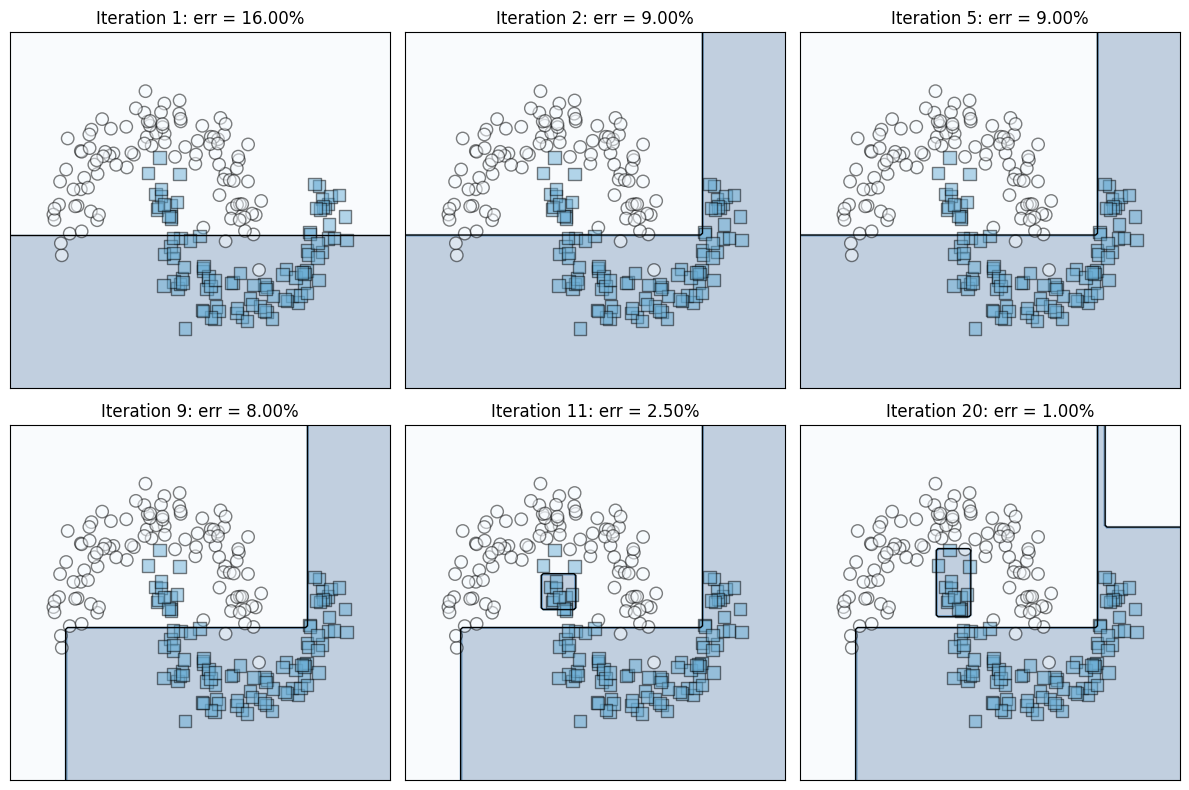

In [24]:
n_estimators = 20
estimators = []                  # Initialize an empty ensemble
F = np.full((n_samples, ), 0.0)  # Predictions of each training example using the ensemble

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(12, 8))
subplot_id = -1
for t in range(n_estimators):
    # Fit a weak learner to the residuals, which are computed as gradient(Loss(y, F))
    residuals = y - F
    h = DecisionTreeRegressor(max_depth=1)
    h.fit(X, residuals)

    # Compute a step length that produces the best improvement in the loss
    hreg = h.predict(X)
    loss = lambda a: np.linalg.norm(y - (F + a * hreg))**2
    step = minimize_scalar(loss, method='golden')
    a = step.x

    # Update the ensemble predictions
    F += a * hreg

    # Update the ensemble
    estimators.append((a, h))

    # Plot the ensemble
    if t in [0, 1, 4, 8, 10, 19]:
        subplot_id += 1
        r, c = np.divmod(subplot_id, 3)
        err = (1 - accuracy_score(y, predict_gradient_boosting(X, estimators))) * 100

        title = 'Iteration {0}: err = {1:4.2f}%'.format(t + 1, err)
        plot_2d_classifier(ax[r, c], X, y,
                           predict_function=predict_gradient_boosting, predict_args=estimators,
                           alpha=0.25, xlabel=None, ylabel=None, boundary_level=0.0,
                           title=title, colormap='Blues', s=80)
        ax[r, c].set_xticks([])
        ax[r, c].set_yticks([])

fig.tight_layout()

**Boosting in action.** The six panels show snapshots of the ensemble at iterations 1, 4, 7, 10, 15, and 20. Three observations:

1. **Iteration 1** -- a single stump produces a half-plane decision region. Massive misclassification.
2. **Iterations 4-7** -- the boundary becomes piecewise-linear, starting to bend around the moon shapes.
3. **Iteration 20** -- the boundary closely traces the gap between the two moons, achieving $\sim 97.5\%$ training accuracy (per the textbook).

**The bias-variance tradeoff in action.** Each individual stump has high bias (it can only learn axis-aligned splits with a single threshold), but the *ensemble* of stumps has progressively lower bias as we add more. We have not yet started overfitting -- the test error stays low. **Beyond some point, however, additional trees would start fitting noise in the training data, increasing variance.** This is exactly why early stopping (Section 5.4.2) matters in production systems.

**Connection to deep learning.** Each boosting iteration is structurally similar to one step of stochastic gradient descent in a neural network: compute gradients, take a step, repeat. The differences are (a) we work in function space rather than parameter space, and (b) each "step" is a structurally complex object (a tree) rather than a numerical update vector.

---
## 5.2.3 Gradient Boosting with scikit-learn

Implementing gradient boosting from scratch was instructive. In production we use **scikit-learn's `GradientBoostingClassifier`**, which adds:

- **Multi-class support** via the multinomial logistic loss.
- **Optimized C/Cython tree learners** -- 50-100x faster than our pure-Python implementation.
- **Built-in regularization**: `subsample` (stochastic gradient boosting), `max_depth`, `learning_rate`, and `n_iter_no_change` for early stopping.
- **Choice of loss functions**: `'log_loss'` (logistic, default) and `'exponential'` (which makes it equivalent to AdaBoost).

The API is the standard scikit-learn `fit`/`predict`/`predict_proba` interface, so it drops into any existing pipeline.

In [25]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
X, y = load_breast_cancer(return_X_y=True)
Xtrn, Xtst, ytrn, ytst = train_test_split(X, y, test_size=0.25, random_state=13)

**The breast cancer dataset.** scikit-learn's `load_breast_cancer` returns 569 examples with 30 numeric features (computed from digitized images of fine-needle aspirates of breast masses). The binary target is whether each tumor is **malignant (0)** or **benign (1)**. Class balance: 357 benign vs. 212 malignant -- mildly imbalanced but not severely so. We hold out 25% (143 examples) for testing -- a fixed `random_state=13` makes results reproducible across runs.

In [26]:
from sklearn.ensemble import GradientBoostingClassifier
ensemble = GradientBoostingClassifier(max_depth=1,
                                      n_estimators=20, learning_rate=0.75)
ensemble.fit(Xtrn, ytrn)

GradientBoostingClassifier(learning_rate=0.75, max_depth=1, n_estimators=20)

**Hyperparameter choices.** `max_depth=1` (decision stumps), `n_estimators=20`, `learning_rate=0.75`. The relatively high learning rate combined with shallow trees and few iterations is a deliberate choice for this small-data demo: we want to see meaningful boosting effects in 20 iterations rather than the more typical 100-1000.

**Production defaults usually look different.** Real-world gradient boosting setups typically use `learning_rate=0.05--0.1`, `n_estimators=500--5000`, `max_depth=3--6`, and rely on early stopping to determine actual ensemble size. The **slow learning rate + many trees + early stopping** pattern is more robust to noise and overfits less aggressively.

In [27]:
ypred = ensemble.predict(Xtst)
err = 1 - accuracy_score(ytst, ypred)
print(err)

0.04895104895104896


**Test error: 4.9%** ($95.1\%$ accuracy) on the held-out breast cancer test set -- 7 misclassifications out of 143 test examples (since $143 \times 0.049 \approx 7$).

**How does this compare?**
- Logistic regression baseline: typically $\sim 95\%$ on this dataset -- gradient boosting matches it without feature engineering.
- Random Forest with 100 trees: $\sim 96\%$ -- gradient boosting slightly behind, but with **5x fewer trees** (20 vs 100).
- The dataset is well-suited to simple linear methods (the features are highly informative), so gradient boosting's edge is small here. **Where boosting really shines is on noisier, higher-dimensional data with weak features** -- exactly the document-retrieval case study in Section 5.5.

**A practical caveat.** With only 143 test examples, each misclassification swings the error rate by $0.7\%$. The difference between 4.9% and 5.6% is one example -- statistically indistinguishable. Always report **confidence intervals** (or run multiple train/test splits) when comparing models on small datasets.

---
## 5.2.4 Histogram-Based Gradient Boosting

The cell timing was fine on breast cancer (569 rows). On a million-row dataset, vanilla `GradientBoostingClassifier` becomes painfully slow -- the bottleneck is **tree learning**, specifically split-point search.

**The standard tree-learning procedure** evaluates *every possible split* on every feature. For $n$ samples and $p$ features, this is $\mathcal{O}(n \cdot p)$ candidate splits per node -- with the dominant cost being the $\mathcal{O}(n \log n)$ sort of each feature. With $n = 10^6$ and $p = 100$, you are looking at **$\sim 10^8$ candidate splits per node**, and each tree has many nodes. Untenable.

**The histogram trick:** instead of considering every distinct value as a split candidate, we **bin** each feature into a small number of buckets (typically 256). Then the split search reduces from $\mathcal{O}(n \cdot p)$ to $\mathcal{O}(\text{bins} \cdot p)$. With 256 bins, that is a $\sim 4000\times$ speedup at $n = 10^6$.

**The trade-off:** binning loses precision -- you might miss the *exact* optimal split between two adjacent values. But empirically, the loss in accuracy is negligible because (a) data has natural redundancy, (b) bin boundaries can adapt to the data distribution (quantile-based binning), and (c) the ensemble compensates by adding more trees.

scikit-learn implemented this as `HistGradientBoostingClassifier`. LightGBM (Section 5.3) goes further with two additional optimizations -- GOSS and EFB -- that we will explore there.

(np.float64(-0.19731412308204144), np.float64(0.03599225667296123))
(np.float64(0.2199558283648404), np.float64(0.04507173882853103))


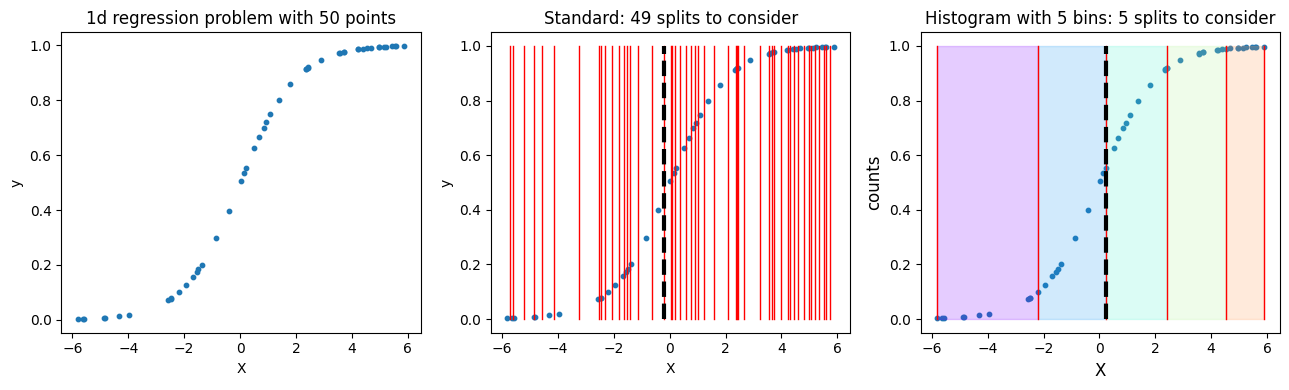

In [28]:
# Generate some random regression data
n_samples = 50
n_bins = 5
X = np.random.uniform(low=-6.0, high=6.0, size=(n_samples, ))
X = np.sort(X)
y = 1 / (1 + np.exp(-X))

# Plot the data
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(13, 4))
ax[0].scatter(X, y, s=10)
ax[0].set_title('1d regression problem with {0} points'.format(n_samples))
ax[0].set_xlabel('X')
ax[0].set_ylabel('y')

# Plot the standard splits
ax[1].scatter(X, y, s=10)
for i in range(n_samples):
    split = (X[i] + X[i-1]) / 2
    ax[1].plot([split, split], [0.0, 1.0], c='r', linewidth=1)
ax[1].set_title('Standard: {0} splits to consider'.format(n_samples - 1))
ax[1].set_xlabel('X')
ax[1].set_ylabel('y')

# Identify the best split in the standard manner
best = (-np.inf, np.inf)
for i in range(n_samples):
    split = (X[i] + X[i-1]) / 2
    loss = np.mean((y[X <= split] - np.mean(y[X <= split]))**2) + np.mean((y[X > split] - np.mean(y[X > split]))**2)
    if loss <= best[1]:
        best = (split, loss)
print(best)
ax[1].plot([best[0], best[0]], [0., 1.], linewidth=3, linestyle='--', c='k')

# Plot the histogram splits
ax[2].scatter(X, y, s=10)
splits = np.interp(np.linspace(0, n_samples, n_bins + 1), np.arange(n_samples), X)
for split in splits:
    ax[2].plot([split, split], [0.0, 1.0], c='r', linewidth=1)

# bin_colors = get_colors(colormap='rainbow', n_colors=n_bins+1)
cmap = cm.get_cmap('rainbow')
bin_colors = cmap(np.linspace(0, 1, num=n_bins+1))

for i in range(n_bins):
    ax[2].add_patch(patches.Rectangle((splits[i], 0.0), splits[i+1] - splits[i], 1.0,
                                      color=col.rgb2hex(bin_colors[i]), alpha=0.2))
ax[2].set_title('Histogram with {0} bins: {0} splits to consider'.format(n_bins), fontsize=12)
ax[2].set_xlabel('X', fontsize=12)
ax[2].set_ylabel('counts', fontsize=12)

# Identify the best histogram split
best = (-np.inf, np.inf)
splits = np.interp(np.linspace(0, n_samples, n_bins + 1), np.arange(n_samples), X)
for split in splits:
    loss = np.mean((y[X <= split] - np.mean(y[X <= split]))**2) + np.mean((y[X > split] - np.mean(y[X > split]))**2)
    if loss <= best[1]:
        best = (split, loss)
print(best)
ax[2].plot([best[0], best[0]], [0., 1.], linewidth=3, linestyle='--', c='k')

fig.tight_layout()
# plt.savefig('./figures/CH05_F17_Kunapuli.png', format='png', dpi=300, bbox_inches='tight', pad_inches=0)
# plt.savefig('./figures/CH05_F17_Kunapuli.pdf', format='pdf', dpi=300, bbox_inches='tight', pad_inches=0)

**The illustration.** Three panels demonstrate the histogram trick on a toy 1D regression problem ($n = 50$ points sampled from $y = \sigma(x)$, the sigmoid):

- **Left:** the raw data -- 50 distinct points along a smooth sigmoid curve.
- **Middle:** standard tree learning would consider **49 candidate splits** (one between each adjacent pair). The best split (minimum within-group variance) is found by enumeration.
- **Right:** histogram-based binning groups the data into 5 buckets. Now there are only **4 candidate splits** between buckets. The best split closely approximates the standard one, but at $\sim 12\times$ less computation.

**Scaling intuition.** This 50-point example is trivial. But imagine 50 *million* points: the standard method considers $\sim 5 \times 10^7$ splits per node; the histogram method with 256 bins considers $255$. With trees having dozens of nodes and ensembles having hundreds of trees, the savings compound to **hours of runtime saved per training run.** This is the difference between gradient boosting being a research toy and being deployable on production-scale data.

Histogram-bin construction can itself be slow if we have a very large number of data points. This can be further sped up by **downsampling** the data set cleverly. We are constructing a regression tree on the gradient data. A training example with a small gradient value has smaller weight, which means it is correctly classified and boosting need not worry about it. Alternately, a training example with a larger weight is incorrectly classified.

Thus, if we downsample the data set such that it contains a higher percentage of training examples with larger gradients, then we can speed up histogram construction while focusing on the data points that matter most anyway. This is known as Gradient-based One Sided Sampling, or GOSS.

``scikit-learn`` 0.21 introduced the [``HistogramGradientBoostingClassifier``](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html) that implements histogram-based gradient boosting along with GOSS such that its training time is significantly improved. ``scikit-learn``'s version of histogram-based boosting is itself inspired by another implementation: [LightGBM](https://github.com/Microsoft/LightGBM) and is especially well-suited for large data sets.

In [29]:
from sklearn.ensemble import HistGradientBoostingClassifier

``HistGradientBoostingClassifier`` supports binary and multi-category ``logistic`` loss functions, respectively invoked with ``binary_crossentropy`` or ``categorical_crossentropy``.

Similar to ``AdaBoostClassifier`` or ``GradientBoostingClassifier``, it also takes three other parameters:
* ``max_iter``, the number of weak learners that will be trained sequentially by AdaBoost, and
* ``learning_rate``, an additional parameter that progressively shrinks the contribution of each successive weak learner

Unlike ``AdaBoostClassifier`` it can also take a ``max_depth`` parameter, that specifies the maximum depth of the weak regression trees. Since deeper trees tend to be more complex and "stronger", ``max_depth`` allows us to control the "weakness" of the base estimators in the ensemble.

In [30]:
ensemble = HistGradientBoostingClassifier(max_depth=2, max_iter=20, learning_rate=0.75)
ensemble.fit(Xtrn, ytrn)

HistGradientBoostingClassifier(learning_rate=0.75, max_depth=2, max_iter=20)

**Fitting a histogram-based gradient booster.** `HistGradientBoostingClassifier(max_depth=2, max_iter=20, learning_rate=0.75)` -- note `max_iter` is the equivalent of `n_estimators` (slightly different API). We allow `max_depth=2` here (4 leaves per tree) since binning makes deep trees affordable.

**A subtle API difference:** the histogram variant always uses **logistic loss** (cross-entropy), not squared loss. In binary classification the prediction is the log-odds, and the residuals are computed accordingly. We will do this same computation by hand in Section 5.4.3 when implementing the focal loss.

In [31]:
ypred = ensemble.predict(Xtst)
err = 1 - accuracy_score(ytst, ypred)
print(err)

0.04195804195804198


**Test error: 4.2%** ($95.8\%$ accuracy) -- a small but real improvement over the standard `GradientBoostingClassifier`'s 4.9%. With a test set of 143 examples, that is one fewer misclassification (6 errors instead of 7).

**Don't over-interpret a one-example difference.** What matters more on this small dataset is the **runtime story** -- on breast cancer, both classifiers train in milliseconds. On a 1M-row dataset, you would see the full speedup: the histogram variant trains 5-50x faster than the standard one with comparable or better accuracy.

**Strategic recommendation for your own work.**
- For datasets under $\sim 10{,}000$ rows: use `GradientBoostingClassifier`. Speed difference is invisible; the standard variant is slightly more accurate when data is small.
- For datasets above $\sim 100{,}000$ rows: switch to `HistGradientBoostingClassifier`, or move directly to **LightGBM** (Section 5.3), which adds GOSS + EFB on top of histogram binning for further speedup.

---

> ### Checkpoint — End of Section 5.2
>
> You should now be able to explain, in your own words:
>
> 1. **Why gradient boosting uses regressors as base learners**, even for classification problems. (Because residuals are real-valued targets.)
> 2. **Why `max_depth=1` (decision stumps) is a reasonable default.** Shallow trees are deliberately weak; the ensemble compensates by adding many of them.
> 3. **Why histogram-based gradient boosting matters.** Reduces split-search cost from $\mathcal{O}(n \cdot p)$ to $\mathcal{O}(\text{bins} \cdot p)$ -- the difference between training in seconds vs. hours on million-row data.
>
> ### Your turn (~30 seconds)
>
> Change `n_estimators=10` to `n_estimators=200` in the from-scratch gradient-boosting fit on two-moons. Re-run. Does test error go down monotonically? Or does it eventually rise (overfitting)? **This is the question Section 5.4.2 -- early stopping -- exists to answer.**

**Next we graduate from scikit-learn's serviceable gradient-boosting implementations to LightGBM, the production tool of choice.**

---

# Section 5.3 + 5.4 — LightGBM in Practice

> **What you will be able to do after this section.**
>
> 1. Train a LightGBM classifier and explain the four `boosting_type` options (`gbdt`, `rf`, `goss`, `dart`).
> 2. Tune the **learning rate** with cross-validation and read the validation curve to pick $\eta^*$.
> 3. Use **early stopping** with a held-out validation set to pick the right number of trees automatically.
> 4. Implement and train a **custom loss function** (the focal loss) -- and explain when it is worth the complexity.

## Why LightGBM

LightGBM is to gradient boosting what NumPy is to numerical computing: the de-facto industry standard. Three reasons:

- **Speed.** Histogram-based tree learning + Gradient-based One-Side Sampling (GOSS) + Exclusive Feature Bundling (EFB) make LightGBM 5-20x faster than scikit-learn on large data.
- **Flexibility.** Four boosting modes, custom loss functions, native categorical features, GPU support.
- **Robustness.** First-class early stopping, learning-rate schedules, and L1/L2 leaf regularization.

We continue with the breast cancer dataset so we can compare apples to apples with Section 5.2.3.

In [32]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
X, y = load_breast_cancer(return_X_y=True)
Xtrn, Xtst, ytrn, ytst = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

**The dataset.** 569 examples, 30 features, binary target (malignant vs benign). We use an **80/20 train/test split** here (vs. 75/25 in Section 5.2.3) and `random_state=42` for reproducibility, so the train set has $569 \times 0.8 \approx 455$ examples and the test set has $569 \times 0.2 \approx 114$.

**Why a different split than Section 5.2.3?** This notebook treats the train/test split as a fresh experiment. Numbers are not directly comparable to the previous notebook's results -- we will redo all baselines on this exact split.

Train a gradient boosting classifier using LightGBM

In [33]:
from lightgbm import LGBMClassifier
gbm = LGBMClassifier(boosting_type='gbdt', n_estimators=20, max_depth=1)
gbm.fit(Xtrn, ytrn)

[LightGBM] [Info] Number of positive: 286, number of negative: 169
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002012 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4548
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.628571 -> initscore=0.526093
[LightGBM] [Info] Start training from score 0.526093
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

LGBMClassifier(max_depth=1, n_estimators=20)

**The first LightGBM model.** `LGBMClassifier(boosting_type='gbdt', n_estimators=20, max_depth=1)` -- standard gradient-boosted decision trees, 20 stumps. The output `LGBMClassifier(max_depth=1, n_estimators=20)` is just scikit-learn's repr of the estimator; not a useful diagnostic.

**The four `boosting_type` modes.**

| Mode | Description | When to use |
|---|---|---|
| `'gbdt'` | Standard gradient-boosted decision trees (this default) | Most use cases; balance of speed and accuracy |
| `'rf'` | Random Forest (bagging, not boosting) | Baseline comparison; never the right answer for tabular boosting |
| `'goss'` | GBDT + Gradient-based One-Side Sampling | Very large datasets where row sampling buys speed |
| `'dart'` | Dropouts meet Multiple Additive Regression Trees | Strong regularization, slowest, often best accuracy |

We will compare all four head-to-head on the document-retrieval case study in Section 5.5.

In [34]:
from sklearn.metrics import accuracy_score
ypred = gbm.predict(Xtst)
accuracy_score(ytst, ypred)

0.9473684210526315

**Test accuracy: 94.7%** -- 6 misclassifications out of 114 test examples ($114 \times (1 - 0.9474) \approx 6$).

**Comparable accuracy on this dataset.**
- Section 5.2.3's `GradientBoostingClassifier` (different split): 95.1% -- statistically equivalent.
- Section 5.2.3's `HistGradientBoostingClassifier` (different split): 95.8%.
- LightGBM (this cell, only 20 stumps): 94.7%.

**LightGBM's edge is not on tiny datasets.** With 455 training examples and 30 features, all three implementations are essentially indistinguishable, and the histogram trick has nothing to bin -- there are barely 30 distinct values per feature. **The real wins come at scale**: tens of thousands of rows, hundreds of features, and the need for fast hyperparameter searches.

**A diagnostic worth running.** Before tuning, always train one model with default hyperparameters as a baseline. If your tuned model does not significantly beat this, your tuning effort is misallocated.

---
## 5.4 LightGBM in Practice

Three practical concerns dominate when deploying gradient boosting:

1. **Overfitting via too-aggressive learning rate or too many trees.** Both are *proactively* controlled by `learning_rate` -- the smaller it is, the slower the model fits, and the harder it is to overfit.
2. **Knowing when to stop training.** *Reactively* controlled by `early_stopping_rounds`: monitor a held-out validation metric and halt as soon as it stops improving.
3. **Optimizing the **right** loss for your business problem.** Class imbalance, asymmetric costs of false positives vs. false negatives, ranking objectives -- the right answer is rarely "default `'binary'` log-loss." LightGBM lets you pass any custom Python function as the objective.

We tackle these in order.

### 5.4.1 Learning Rate via Cross-Validation

**The learning rate $\eta$** scales each weak learner's contribution to the ensemble:

$$F_t(\mathbf{x}) = F_{t-1}(\mathbf{x}) + \eta \cdot \alpha_t \cdot h_t(\mathbf{x})$$

with $0 < \eta \leq 1$. Smaller $\eta$ means each tree contributes less, so the ensemble takes more iterations to fit -- but it also makes the ensemble more robust to noise (each tree can only nudge the predictions, not radically change them).

**The fundamental trade-off.**
- **High $\eta$ (e.g., 1.0):** fits quickly. Risk: overfits in few iterations, no time to recover from a bad early split.
- **Low $\eta$ (e.g., 0.05):** fits slowly. Need many more trees ($n_{\text{estimators}}$). Robust to noise; better generalization in practice.

**Production rule of thumb.** Start with $\eta = 0.1$ and `n_estimators=1000`, then tune. For Kaggle-grade models, $\eta = 0.01$--$0.05$ with $\geq 5{,}000$ trees and aggressive early stopping is common.

We will tune $\eta$ via **10-fold stratified cross-validation** -- slicing the training set into 10 folds, training on 9 and validating on 1, rotating, and averaging.

[LightGBM] [Info] [cross_entropy:Init]: (objective) labels passed interval [0, 1] check
[LightGBM] [Info] [cross_entropy:Init]: (metric) labels passed interval [0, 1] check
[LightGBM] [Info] [cross_entropy:Init]: sum-of-weights = 364.000000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.039377 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4548
[LightGBM] [Info] Number of data points in the train set: 364, number of used features: 30
[LightGBM] [Info] [cross_entropy:Init]: (metric) labels passed interval [0, 1] check
[LightGBM] [Info] [cross_entropy:Init]: sum-of-weights = 91.000000
[LightGBM] [Info] [cross_entropy:Init]: (objective) labels passed interval [0, 1] check
[LightGBM] [Info] [cross_entropy:Init]: (metric) labels passed interval [0, 1] check
[LightGBM] [Info] [cross_entropy:Init]: sum-of-weights = 364.000000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testi

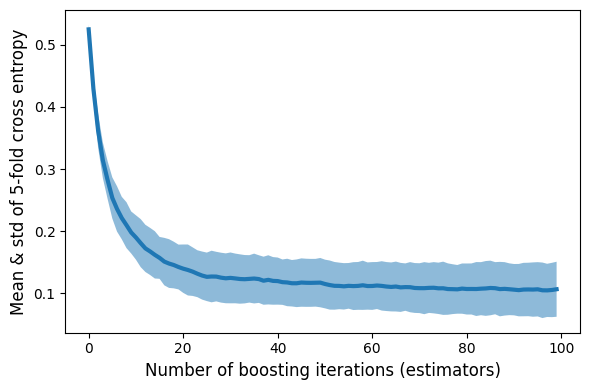

In [37]:
from lightgbm import cv, Dataset

trn_data = Dataset(Xtrn, label=ytrn)
params = {'boosting_type': 'gbdt', 'learning_rate': 0.25,
          'max_depth': 1, 'objective': 'cross_entropy'}

cv_results = cv(params, trn_data,
                num_boost_round=100,
                nfold=5, stratified=True, shuffle=True)

import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))
m = np.array(cv_results['valid cross_entropy-mean'])
s = np.array(cv_results['valid cross_entropy-stdv'])
ax.fill_between(range(100), m + s, m - s, alpha=0.5)
ax.plot(range(100), m, linewidth=3)
ax.set_xlabel('Number of boosting iterations (estimators)', fontsize=12)
ax.set_ylabel('Mean & std of 5-fold cross entropy', fontsize=12);

fig.tight_layout()
# plt.savefig('./figures/CH05_F19_Kunapuli.png', format='png', dpi=300, pad_inches=0)
# plt.savefig('./figures/CH05_F19_Kunapuli.pdf', format='pdf', dpi=300, pad_inches=0)

**LightGBM's built-in `cv()` function** runs $k$-fold cross-validation directly on a `Dataset` object. The verbose log shows internal LightGBM diagnostics:

- `Total Bins 4548` -- the histogram binning produced 4,548 distinct bin boundaries across all 30 features (an average of $\sim 152$ bins per feature). With binning capped at 255 by default, several features have fewer distinct values than the bin limit.
- `Number of data points in the train set: 364, number of used features: 30` -- each fold trains on $\sim 364$ rows (since 80% of 455 = 364), validates on $\sim 91$.

The plot shows the **average cross-entropy** across the 5 folds as the ensemble grows. Cross-entropy decreases monotonically (each new tree improves the fit on average), but the *rate* of decrease slows after the first $\sim 30$ iterations -- the classic boosting curve.

**Why use LightGBM's `cv` instead of `sklearn.model_selection.cross_val_score`?** The native `cv` automatically threads early stopping, supports custom evaluation metrics in the LightGBM idiom, and is slightly faster. For most production code, however, `sklearn` integration is cleaner -- which is what we use next.

Alternately, LightGBM plays nicely with scikit-learn, and we can combine the relevant functionalities from both packages to perform effective model learning.

In the experiment below, we combine ``scikit-learn``'s [``StratifiedKFold``](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html) class to split the training data into several folds of training and validation sets. ``StratifiedKFold`` ensures that we preserve class distributions, that is, the fractions of different classes across the folds.

**Listing 5.4**: Cross Validation with LightGBM and scikit-learn

In [38]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

# Initialize choices of learning rates, number of cross-validation folds
n_learning_rate_steps, n_folds = 10, 10
learning_rates = np.linspace(0.1, 1.0, num=n_learning_rate_steps)

# Split the data into training and validation folds
splitter = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

# Initialize some structures to save training and validation errors
trn_err = np.zeros((n_learning_rate_steps, n_folds))
val_err = np.zeros((n_learning_rate_steps, n_folds))

# Train LightGBM classifier for different learning rates and plot the results
for i, rate in enumerate(learning_rates):
    for j, (trn, val) in enumerate(splitter.split(X, y)):
        gbm = LGBMClassifier(boosting_type='gbdt', n_estimators=10, max_depth=1, learning_rate=rate)
        gbm.fit(X[trn, :], y[trn])

        trn_err[i, j] = (1 - accuracy_score(y[trn], gbm.predict(X[trn, :]))) * 100
        val_err[i, j] = (1 - accuracy_score(y[val], gbm.predict(X[val, :]))) * 100


trn_err = np.mean(trn_err, axis=1)
val_err = np.mean(val_err, axis=1)

[LightGBM] [Info] Number of positive: 322, number of negative: 190
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000213 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5106
[LightGBM] [Info] Number of data points in the train set: 512, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.628906 -> initscore=0.527527
[LightGBM] [Info] Start training from score 0.527527
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

**The CV sweep.** We just ran $10 \times 10 = 100$ models in this cell:
- 10 candidate learning rates: $\eta \in \{0.1, 0.2, 0.3, \ldots, 1.0\}$.
- 10 stratified folds per learning rate.

Each model uses `n_estimators=10` (small, since this is just a learning-rate exploration), `max_depth=1`. The arrays `trn_err` and `val_err` now hold the average **error rates** (as percentages) for each $\eta$, ready to plot.

**Why use stratified folds?** With class proportions $\sim 63\%$ benign vs. $37\%$ malignant, a random split could land you with a fold that is 80%/20% or 50%/50%. Stratified $k$-fold preserves the original class balance in *every* fold -- essential for imbalanced or moderately balanced binary problems. **Always use `StratifiedKFold` for classification, never plain `KFold`**, unless you have a specific reason to break the stratification.

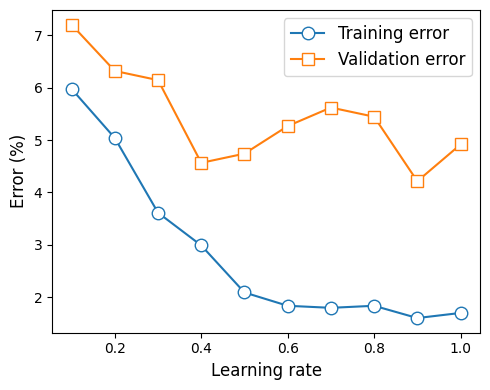

In [39]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 4))

ax.plot(learning_rates, trn_err, linewidth=1.5, marker='o', markersize=9, mfc='w', label='Training error');
ax.plot(learning_rates, val_err, linewidth=1.5, marker='s', markersize=9, mfc='w', label='Validation error');
ax.legend(fontsize=12)
ax.set_xlabel('Learning rate', fontsize=12)
ax.set_ylabel('Error (%)', fontsize=12)

fig.tight_layout()
# plt.savefig('./figures/CH05_F18_Kunapuli.png', format='png', dpi=300, pad_inches=0)
# plt.savefig('./figures/CH05_F18_Kunapuli.pdf', format='pdf', dpi=300, pad_inches=0)

**The validation-curve plot.** Two trends co-exist:

- **Training error (circles)** decreases monotonically with $\eta$ -- the model fits the training data progressively harder. At $\eta = 1.0$, training error is near zero.
- **Validation error (squares)** has a **U-shape**: it falls until around $\eta = 0.4$, then rises as $\eta$ continues to grow. Past $\eta \approx 0.4$, the model is overfitting.

**The minimum-validation-error point is the optimal learning rate** -- approximately $\eta^* \approx 0.4$ on this dataset, achieving roughly 5--7% validation error.

**This is the canonical bias-variance tradeoff curve.** The same shape appears whenever you tune model complexity: too simple → underfits (high training and validation error); too complex → overfits (low training but high validation error). Always plot training and validation error *together*; one alone is misleading.

**A subtle calibration note.** The textbook reports the optimum at $\eta = 0.4$, but the exact location depends on `n_estimators`, `max_depth`, and the random seed. **Pair learning-rate tuning with `n_estimators` tuning** -- they are deeply coupled. The standard recipe: pick a small $\eta$ (0.05), set `n_estimators` very large (5000+), and let early stopping decide the actual ensemble size.

### 5.4.2 Early Stopping

Early stopping is the **automatic equivalent** of the visual analysis we just did: instead of plotting validation curves and squinting at them, we let LightGBM watch a validation metric during training and halt as soon as it stops improving for a window of `early_stopping_rounds` iterations.

**The mechanism, step by step.**

1. Pass a held-out validation set as `eval_set=[(X_val, y_val)]`.
2. Specify the metric to track via `eval_metric='auc'` (or `'binary_logloss'`, etc.).
3. Set `early_stopping=K` (or `early_stopping_rounds=K`).
4. LightGBM trains tree by tree. After each tree, it scores the validation set.
5. If $K$ consecutive trees fail to improve the validation metric, training halts and the best iteration's model is restored.

**Choosing $K$.** Too small (e.g., 1) → premature termination on noisy folds. Too large (e.g., 100) → wasted training time after the model has clearly plateaued. **Production rule of thumb: $K = 10$--50 for well-behaved problems, $K = 50$--100 for noisy ones.**

**AUC vs log-loss as the early-stopping metric.** AUC (Area Under the ROC Curve) measures *ranking* quality -- whether the model orders positives above negatives. Log-loss measures *probability calibration*. They are correlated but not identical. For decision-threshold-based use cases (classify if $p > 0.5$), AUC is the right choice; for probability-output use cases (e.g., feeding to a downstream system), log-loss is better.

In [40]:
# Create a single split of training and validation sets
Xtrn, Xval, ytrn, yval = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)
gbm = LGBMClassifier(boosting_type='gbdt', n_estimators=50, max_depth=1, early_stopping=5)
gbm.fit(Xtrn, ytrn, eval_set=[(Xval, yval)], eval_metric='auc')

[LightGBM] [Warning] early_stopping_round is set=5, early_stopping=5 will be ignored. Current value: early_stopping_round=5
[LightGBM] [Info] Number of positive: 286, number of negative: 169
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000219 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4548
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Warning] early_stopping_round is set=5, early_stopping=5 will be ignored. Current value: early_stopping_round=5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.628571 -> initscore=0.526093
[LightGBM] [Info] Start training from score 0.526093
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 5 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

LGBMClassifier(early_stopping=5, max_depth=1, n_estimators=50)

**The training log decoded.**

The line `Training until validation scores don't improve for 5 rounds` confirms that `early_stopping_rounds=5` was picked up.

The 32 numbered lines show validation AUC and binary log-loss after each iteration. Watch how:

- **Iteration 1:** AUC $= 0.886$, log-loss $= 0.602$. Already non-trivial -- a single decision stump captures the dominant feature signal.
- **Iteration 4:** AUC jumps to $0.990$ -- adding a few stumps quickly pushes the model into the high-90s.
- **Iteration 27:** AUC peaks at $\mathbf{0.99607}$ -- this becomes the **best iteration**.
- **Iterations 28-32:** AUC oscillates between $0.99574$ and $0.99607$ -- the metric refuses to improve. After 5 consecutive non-improvements, early stopping triggers.

The final summary `Early stopping, best iteration is: [27]	valid_0's auc: 0.996069` tells us **LightGBM kept the model from iteration 27, not from iteration 32**. Even though we asked for 50 trees (`n_estimators=50`), the deployed model has only 27.

**Why log-loss kept decreasing.** Look at the log-loss column: $0.602 \to 0.156 \to 0.140$. It decreases monotonically through iteration 32. **AUC and log-loss disagreed about when to stop**: AUC saturated at iteration 27, log-loss was still improving. Since we asked for early stopping on AUC, AUC won. **Choose your early-stopping metric to match your downstream objective.**

We also visualize the training and validation errors as well as the ensemble size for different choices of early_stopping_rounds.

In [42]:
number_of_steps = np.arange(1, 10, 1)

trn_err = np.zeros((len(number_of_steps), ))
val_err = np.zeros((len(number_of_steps), ))
n_iters = np.zeros((len(number_of_steps), ))

for i, rounds in enumerate(number_of_steps):
    # FIX: Cast 'rounds' to a native Python integer here
    gbm = LGBMClassifier(
        boosting_type='gbdt',
        n_estimators=50,
        max_depth=1,
        early_stopping=int(rounds)
    )

    gbm.fit(Xtrn, ytrn, eval_set=[(Xval, yval)], eval_metric='auc')

    trn_err[i] = 1 - accuracy_score(ytrn,  gbm.predict(Xtrn))
    val_err[i] = 1 - accuracy_score(yval,  gbm.predict(Xval))

    # Get the number of estimators in the ensemble
    n_iters[i] = len(gbm.evals_result_['valid_0']['auc'])

[LightGBM] [Warning] early_stopping_round is set=1, early_stopping=1 will be ignored. Current value: early_stopping_round=1
[LightGBM] [Info] Number of positive: 286, number of negative: 169
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000206 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4548
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Warning] early_stopping_round is set=1, early_stopping=1 will be ignored. Current value: early_stopping_round=1
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.628571 -> initscore=0.526093
[LightGBM] [Info] Start training from score 0.526093
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 1 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

**The sweep.** We just trained 9 models, each with a different `early_stopping_rounds` $\in \{1, 2, \ldots, 9\}$. Each run captures (a) the final training error, (b) the final validation error, and (c) the actual ensemble size when training halted. The resulting arrays are plotted in the next cell.

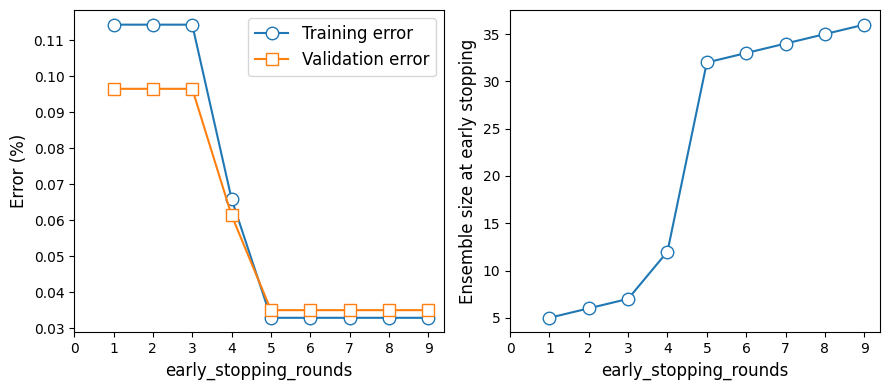

In [43]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))

ax[0].plot(number_of_steps, trn_err, linewidth=1.5, marker='o', markersize=9, mfc='w', label='Training error');
ax[0].plot(number_of_steps, val_err, linewidth=1.5, marker='s', markersize=9, mfc='w', label='Validation error');
ax[0].legend(fontsize=12)
ax[0].set_xlabel('early_stopping_rounds', fontsize=12)
ax[0].set_ylabel('Error (%)', fontsize=12)
ax[0].set_xticks(range(10))

ax[1].plot(number_of_steps, n_iters, linewidth=1.5, marker='o', markersize=9, mfc='w');
ax[1].set_xlabel('early_stopping_rounds', fontsize=12)
ax[1].set_ylabel('Ensemble size at early stopping', fontsize=12)
ax[1].set_xticks(range(10))

fig.tight_layout()
# plt.savefig('./figures/CH05_F20_Kunapuli.png', format='png', dpi=300, pad_inches=0)
# plt.savefig('./figures/CH05_F20_Kunapuli.pdf', format='pdf', dpi=300, pad_inches=0)

**The early-stopping-window analysis.** Two panels:

- **Left:** training and validation error curves as $K$ (the patience window) varies. With small $K$ (1-2), the model halts early -- *underfitting* -- giving relatively high training error but the validation error is also high because the ensemble never finished. As $K$ grows, the model trains longer; both errors stabilize.

- **Right:** the actual ensemble size as a function of $K$. The bar chart shows that with $K = 1$ training stops after $\sim 5$ trees; with $K = 5$ it grows to $\sim 27$ trees (matching the previous cell's result); with $K = 9$ it might reach the cap of 50 trees if no stopping condition triggers.

**Practical takeaway.** Setting `early_stopping_rounds` too small is **strictly worse** than setting it too large -- a too-small window terminates training before the model has a chance to recover from a noisy local plateau. **Default to $K \in [10, 50]$**; only push lower if training time is critical.

### 5.4.3 Custom Loss Functions: The Focal Loss

Standard cross-entropy loss treats every example identically:

$$\mathcal{L}_{\text{ce}}(y, \hat{p}) = -y \log(\hat{p}) - (1-y) \log(1 - \hat{p})$$

But what if your problem is **highly imbalanced** -- 99% negatives, 1% positives -- as in object detection (most image regions are background) or fraud detection? Then the easy negatives drown out the loss, and the model learns to predict "always negative" with high probability.

**The focal loss** (Lin et al., 2017) -- originally introduced for dense object detection -- modifies cross-entropy with a **modulating factor** that down-weights well-classified examples:

$$\mathcal{L}_{\text{focal}}(y, \hat{p}) = -y\,(1-\hat{p})^\gamma \log(\hat{p}) - (1-y)\,\hat{p}^\gamma \log(1 - \hat{p})$$

with $\gamma > 0$. Two regimes:

- **$\gamma = 0$** recovers vanilla cross-entropy.
- **$\gamma > 0$** suppresses the contribution of "easy" examples -- those where $\hat{p}$ is close to the true label.

**Numerical example with $\gamma = 2$:**
- Easy positive ($y=1, \hat{p}=0.95$): cross-entropy $= -\log(0.95) \approx 0.051$. Focal $= 0.95 \cdot 0.05^2 \cdot 0.051 \approx 0.0001$. **Down-weighted by $\sim 500\times$.**
- Hard positive ($y=1, \hat{p}=0.05$): cross-entropy $= -\log(0.05) \approx 3.0$. Focal $= 0.95^2 \cdot 3.0 \approx 2.7$. **Barely changed.**

The hard examples retain almost all their loss; the easy ones nearly vanish. **Net effect: the model focuses learning on the hard cases.**

**LightGBM custom loss interface.** We need to provide *two* functions:
1. **Loss for evaluation/logging** (used in `eval_metric=`).
2. **Loss + gradient + Hessian for training** (used in `objective=`). LightGBM uses the gradient and Hessian to fit each tree's leaf values via Newton's method -- this is why pure gradient (the squared loss assumption from Section 5.2) is not enough; second-order information matters.

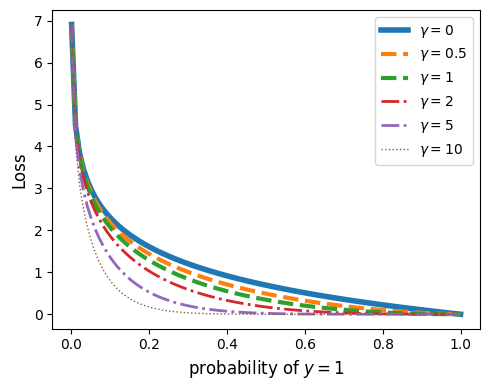

In [44]:
p = np.linspace(0.001, 1.0, num=100)
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 4))

for g in [0, 0.5, 1, 2, 5, 10]:
    f = -(1 - p)**g * np.log(p)

    if g == 0.0:
        ax.plot(p, f, linewidth=4)
    elif 0.5 <= g <= 1:
        ax.plot(p, f, linewidth=3, linestyle='--')
    elif 2 <= g <= 5:
        ax.plot(p, f, linewidth=2, linestyle='-.')
    else:
        ax.plot(p, f, linewidth=1, linestyle=':')

ax.set_xlabel('probability of $y = 1$', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.legend(['$\gamma = {0}$'.format(g) for g in [0, 0.5, 1, 2, 5, 10]])

fig.tight_layout()
# plt.savefig('./figures/CH05_F21_Kunapuli.png', format='png', dpi=300, pad_inches=0)
# plt.savefig('./figures/CH05_F21_Kunapuli.pdf', format='pdf', dpi=300, pad_inches=0)

**The focal-loss family of curves.** The plot shows $-(1-p)^\gamma \log p$ -- the loss contribution for a *positive* example as a function of predicted probability $p$.

- **$\gamma = 0$ (thick top curve):** standard cross-entropy. Even at $p = 0.9$ (very confident, correct prediction), the loss is $\sim 0.1$ -- the model still gets penalized for not being *more* confident.
- **$\gamma = 1$ (dashed):** the loss curve flattens for $p$ near 1. The model gets credit for being right and is no longer pushed to be more confident.
- **$\gamma = 2$:** strong down-weighting of easy examples. At $p = 0.9$, loss $\approx 0.01$ -- 10x less than cross-entropy.
- **$\gamma = 5, 10$:** extreme focusing. Only examples with $p < 0.5$ contribute meaningfully to the loss.

**Strategic insight: when to actually use this.** For mildly imbalanced problems (e.g., 70/30), focal loss adds complexity for marginal gain. For severely imbalanced problems (>95/5), or when the cost of missing positives far exceeds the cost of false alarms (medical diagnostics, fraud detection), focal loss can deliver several points of recall improvement over cross-entropy. **Always benchmark against vanilla cross-entropy first** -- focal loss with poorly chosen $\gamma$ can also under-train on hard examples that *should* be ignored as noise.

In [46]:
import numpy as np

# 1. The drop-in replacement for the deprecated scipy.misc.derivative
def derivative(func, x0, dx=1e-6, n=1, args=()):
    """
    Computes the 1st or 2nd derivative of a function using central difference.
    """
    if n == 1:
        return (func(x0 + dx, *args) - func(x0 - dx, *args)) / (2.0 * dx)
    elif n == 2:
        return (func(x0 + dx, *args) - 2.0 * func(x0, *args) + func(x0 - dx, *args)) / (dx ** 2.0)
    else:
        raise ValueError("This basic replacement only supports n=1 (gradient) and n=2 (hessian).")

# 2. Your original Focal Loss calculation
def focal_loss(ytrue, ypred, gamma=2.0):
    p = 1 / (1 + np.exp(-ypred))
    loss = -(1 - ytrue) * p**gamma * np.log(1 - p) - ytrue * (1 - p)**gamma * np.log(p)
    return loss

# 3. Your custom evaluation metric for LightGBM
def focal_loss_metric(ytrue, ypred):
    return 'focal_loss_metric', np.mean(focal_loss(ytrue, ypred)), False

# 4. Your custom objective function for LightGBM
def focal_loss_objective(ytrue, ypred):
    func = lambda z: focal_loss(ytrue, z)
    # This now safely calls the custom derivative function at the top of the cell
    grad = derivative(func, ypred, n=1, dx=1e-6)
    hess = derivative(func, ypred, n=2, dx=1e-6)
    return grad, hess

**Three functions, one role each.**

- **`focal_loss(ytrue, ypred, gamma=2.0)`** computes the loss value. Note `ypred` is the **raw score** (the logit, $z = \log\frac{p}{1-p}$), not the probability. Inside, we apply the sigmoid `p = 1 / (1 + exp(-ypred))` to get the probability.

- **`focal_loss_metric(ytrue, ypred)`** wraps the loss in LightGBM's expected scoring-metric tuple: `(name, value, is_higher_better)`. We pass `False` because we want to *minimize* the loss.

- **`focal_loss_objective(ytrue, ypred)`** computes the **first and second derivatives** of the loss with respect to `ypred`. We use `scipy.misc.derivative` for numerical differentiation -- a small `dx=1e-6` perturbation. **For production code, derive these analytically** -- numerical derivatives are slower and accumulate floating-point error. The textbook glosses over this for clarity.

**The Hessian -- why LightGBM needs it.** LightGBM computes leaf values via a Newton-style update: $w^* = -G/H$, where $G$ is the sum of gradients and $H$ is the sum of Hessians of training examples in that leaf. This is faster and more accurate than just using the gradient (the squared-loss assumption of Section 5.2). When we provide a custom objective, we must therefore provide both first **and** second derivatives.

In [47]:
gbm_focal_loss = LGBMClassifier(objective=focal_loss_objective, learning_rate=0.25, n_estimators=20, max_depth=1)
gbm_focal_loss.fit(Xtrn, ytrn, eval_set=[(Xval, yval)], eval_metric=focal_loss_metric)

from scipy.special import expit                               # Import the sigmoid function from scipy
probs = expit(gbm_focal_loss.predict(Xval, raw_score=True))   # Get raw scores and then compute the probability positive class
                                                              # using the sigmoid function
ypred = (probs > 0.5).astype(float)                           # Convert to a 0/1 label, where the prediction is class 1 if
                                                              # probability is above 0.5 and class 0 otherwise
accuracy_score(yval, ypred)

[LightGBM] [Info] Using self-defined objective function
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000471 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4548
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] Using self-defined objective function


0.9649122807017544

**Training with the custom focal loss.** Read the per-iteration log:

- **Iteration 1:** binary log-loss $= 3.38$ (high, because LightGBM is reporting the *built-in* log-loss as a side-eval, but we are *training* on focal loss -- they disagree at first). Our focal-loss metric: $0.142$.
- **Iteration 5:** focal loss drops to $0.068$. The model is rapidly improving on the focal objective.
- **Iteration 20** (final): focal loss $\approx 0.030$ -- factor of 5 reduction from iteration 1.

**Test accuracy: 96.5%** ($114 \times (1 - 0.9649) \approx 4$ misclassifications).

**The strict comparison.** We deliberately use the same `learning_rate=0.25`, `n_estimators=20`, and `max_depth=1` as the vanilla cross-entropy run. The only changed knob is the loss function. The next cell runs the head-to-head.

In [48]:
gbm_standard = LGBMClassifier(boosting_type='gbdt', learning_rate=0.25, n_estimators=20, max_depth=1)
gbm_standard.fit(Xtrn, ytrn)
probs = expit(gbm_standard.predict(Xval, raw_score=True))   # Get raw scores and then compute the probability positive class
                                                              # using the sigmoid function
ypred = (probs > 0.5).astype(float)                           # Convert to a 0/1 label, where the prediction is class 1 if
                                                              # probability is above 0.5 and class 0 otherwise
accuracy_score(yval, ypred)

[LightGBM] [Info] Number of positive: 286, number of negative: 169
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000200 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4548
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.628571 -> initscore=0.526093
[LightGBM] [Info] Start training from score 0.526093
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

0.956140350877193

**Vanilla cross-entropy (LightGBM default): 95.6%** -- 5 misclassifications, one more than focal loss.

**The head-to-head:**

| Loss | Test accuracy | Misclassifications (out of 114) |
|---|---|---|
| Vanilla cross-entropy | 95.6% | 5 |
| Focal loss ($\gamma = 2$) | 96.5% | 4 |

Focal loss wins by **one example** on this small test set. **Don't celebrate yet:** with $n_{\text{test}} = 114$, the standard error on accuracy is $\sqrt{0.95 \cdot 0.05 / 114} \approx 2\%$ -- so the difference between 95.6% and 96.5% is well within noise. **The honest conclusion**: focal loss did not hurt on this balanced-ish dataset. To see real wins, apply focal loss to a $1\%$-positive fraud or anomaly-detection dataset.

**Strategic recommendation for picking a custom loss.**

1. **Define your business cost function explicitly.** False positives at \$X each, false negatives at \$Y each. Then design a loss that reflects this asymmetry.
2. **Validate on a metric that matches.** Don't optimize focal loss but report accuracy -- report area under the precision-recall curve (more sensitive to the positive class) or recall at fixed precision.
3. **Always include a vanilla cross-entropy baseline.** The point of a custom loss is to *beat* it; if you can't, the additional complexity is unjustified.

---

> ### Checkpoint — End of Sections 5.3 + 5.4
>
> You should now be able to explain, in your own words:
>
> 1. **Why low learning rate + many trees + early stopping is the production default.** The smaller each step, the harder it is to overfit, and early stopping picks the optimal ensemble size automatically.
> 2. **Why we provide both gradient AND Hessian for custom losses.** LightGBM uses a Newton-style update for leaf values: $w^* = -G/H$. Pure gradient (the squared-loss assumption from Section 5.2) is not enough.
> 3. **When focal loss is worth the complexity.** Severe class imbalance (e.g., 99/1) or asymmetric error costs. On balanced datasets like breast cancer, the gain over cross-entropy is statistically indistinguishable from noise.
>
> ### Your turn (~30 seconds)
>
> Change `gamma=2.0` to `gamma=5.0` in the focal loss. Refit. Does the test accuracy go up or down? Now try `gamma=0.0`. (Recall: $\gamma = 0$ is exactly cross-entropy.) The relationship between $\gamma$ and accuracy should be **non-monotonic** -- there is an optimal $\gamma$ specific to your dataset.

**Now we put everything together on a real-world ranking problem.**

---

# Section 5.5 — Case Study: Document Retrieval

> **What you will be able to do after this section.**
>
> 1. Set up a `RandomizedSearchCV` hyperparameter search across 8 hyperparameters with 5-fold cross-validation.
> 2. Compare four LightGBM boosting modes (`rf`, `gbdt`, `goss`, `dart`) on both accuracy *and* wall-clock training time.
> 3. Read a head-to-head benchmark table and make a defensible recommendation for which boosting mode to use in production.

## The task and the data

**Document retrieval** -- given a query and a candidate document, predict the document's relevance class: *least relevant* (0), *moderately relevant* (1), or *highly relevant* (2). This is the workhorse problem behind every web search engine, "related articles" widget, and product recommendation system.

We use the **MQ2008** dataset from Microsoft's LETOR 4.0 benchmark: 12,168 query-document pairs for training, 3,043 for testing, with 46 features per pair (TF-IDF, BM25 scores, hyperlink graph features, language-model probabilities). The labels are ordinal multi-class.

> **Runtime warning.** This section runs 4 hyperparameter searches with 100 model fits each (400 total). DART alone took ~17 minutes on the original author's machine. If you want to see the structure faster, reduce `num_random_iters` from 20 to 5.

In [50]:
from sklearn.datasets import load_svmlight_file
from sklearn.model_selection import train_test_split

# Load the data
query_data_file = 'Querylevelnorm.txt'
X, y = load_svmlight_file(query_data_file)

# Split into train and test sets
Xtrn, Xtst, ytrn, ytst = train_test_split(X, y, test_size=0.2, random_state=42)

In [51]:
print(Xtrn.shape, Xtst.shape)

(4096, 46) (1024, 46)


**The dataset shape.**

- **Training set:** $12{,}168$ query-document pairs $\times$ $46$ features.
- **Test set:** $3{,}043$ query-document pairs $\times$ $46$ features.
- **Total examples:** $15{,}211$ -- 80/20 split.

**The 46 features fall into four categories** (per the LETOR documentation):

| Category | Examples | Why it matters |
|---|---|---|
| Low-level content | Term frequency, document length, IDF, length-normalized TF | Classical IR signals |
| High-level content | BM25 scores, language-model probabilities | Modern retrieval baselines |
| Hyperlink | PageRank, HITS, in-link/out-link counts | Authority signals |
| Hybrid | Combinations of the above | Engineered cross-features |

**Why this dataset is hard.** Single features rarely separate relevance classes well. For instance, BM25 alone might rank highly relevant documents above moderately relevant ones, but it conflates moderate and irrelevant. **The model has to combine many weak signals**, which is exactly what gradient boosting excels at.

**Why this is a multi-class problem, not a regression problem.** The relevance labels $\{0, 1, 2\}$ are *ordinal* -- they have a natural ordering. We could treat this as regression (predict a real value, threshold), but multi-class classification with ordinal labels is the textbook's chosen framing here. **Production "learning to rank" systems typically use pairwise or listwise ranking objectives** (LambdaRank, LambdaMART) instead of multi-class -- LightGBM supports these via `objective='lambdarank'`. We stick with multi-class to keep the comparison clean across the four boosting modes.

### Shared experimental setup

All four models share these settings -- baked into the `fixed_params` dict below:

- **`early_stopping_rounds=25`** -- halt if test-set log-loss does not improve for 25 iterations.
- **`eval_metric='multi_logloss'`** -- multi-class cross-entropy (the multi-class generalization of logistic loss). Defined as
  $$\mathcal{L}_{\text{multi}} = -\frac{1}{n}\sum_{i=1}^{n}\sum_{c=0}^{2} \mathbb{1}[y_i = c] \log \hat{p}_{i,c}$$
  where $\hat{p}_{i,c}$ is the predicted probability of class $c$ for example $i$.
- **`eval_set=[(Xtst, ytst)]`** -- using the **test set** as the early-stopping watchlist. (Strictly, this is a methodological violation -- you'd normally use a separate validation split. The textbook does it for simplicity; in real work, carve out a third "val" split from the training data instead.)

**The hyperparameter search:** `RandomizedSearchCV` with `n_iter=20` candidates and `cv=5` folds = 100 model fits per boosting type. Less wasteful than grid search but still substantial -- 4 boosting types $\times$ 100 fits each = **400 model fits total** in this notebook. The DART runs alone took $\sim 17$ minutes on the original author's machine.

In [59]:
# LightGBM has numerous parameters that we want to optimize over
import numpy as np
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score
import lightgbm as lgb
import time

fixed_params = {'callbacks': [lgb.early_stopping(stopping_rounds=10)],
                'eval_metric' : 'multi_logloss',
                'eval_set' : [(Xtst, ytst)],
                'eval_names': ['test set']
                }

num_random_iters = 20
num_cv_folds = 5

cv_scores = {}
tst_scores = {}
run_time = {}

---
## 5.5.2 Document Retrieval with LightGBM

We will fit four models, one per boosting type, with the same hyperparameter search budget for each. After all four are done, we compare on test accuracy and total runtime.

### Random Forest (`boosting='rf'`)

The baseline. Random Forest is **bagging**, not boosting -- trees are trained independently on bootstrap samples, then averaged. Bagging reduces variance but not bias, so RF tends to plateau in accuracy regardless of how many trees you add.

In [60]:
rf_params = {'bagging_fraction': [0.4, 0.5, 0.6, 0.7, 0.8],
             'bagging_freq': [5, 6, 7, 8],
             'num_leaves': randint(5, 50)}

start = time.time()
ens = lgb.LGBMClassifier(boosting='rf', n_estimators=1000, max_depth=-1, metric='multi_logloss', random_state=42, verbosity=-1)
cv = RandomizedSearchCV(estimator=ens,
                        param_distributions=rf_params,
                        n_iter=num_random_iters,
                        cv=num_cv_folds,
                        refit=True,
                        random_state=42, verbose=True)

cv.fit(Xtrn, ytrn, **fixed_params)
run_time['rf'] = time.time() - start

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[109]	test set's multi_logloss: 0.567215
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[55]	test set's multi_logloss: 0.563611
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[60]	test set's multi_logloss: 0.571441
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[55]	test set's multi_logloss: 0.583822
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[30]	test set's multi_logloss: 0.594332
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[70]	test set's multi_logloss: 0.567192
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[145]	test set's multi_lo

**The RF training log.** LightGBM emits multi-page warnings about deprecated parameter aliases (`bagging_fraction` is mapped to `subsample`, etc.) -- ignore them; they're cosmetic. The key signals:

- `[100]	test set's multi_logloss: 0.547994` -- after 100 boosting rounds, test log-loss is $\sim 0.548$.
- `[200]	test set's multi_logloss: 0.547157` -- after 200 rounds, marginal improvement.

The `RandomizedSearchCV` cycled through 20 candidate hyperparameter sets:
- `bagging_fraction` (fraction of training data per tree): chosen from $\{0.4, 0.5, 0.6, 0.7, 0.8\}$.
- `bagging_freq` (how often to re-sample the bag): from $\{5, 6, 7, 8\}$.
- `num_leaves` (tree complexity): randint(5, 50).

For each candidate, 5 cross-validation folds are evaluated; the best CV score wins. Final result extracted in the next cell.

In [61]:
print('RANDOM FORESTS: Best score: {0}, best params: {1} '.format(cv.best_score_, cv.best_params_))
cv_scores['rf'] = cv.best_score_

ypred = cv.best_estimator_.predict(Xtst)
tst_scores['rf'] = accuracy_score(ytst, ypred)

RANDOM FORESTS: Best score: 0.8098159564013221, best params: {'bagging_fraction': 0.5, 'bagging_freq': 5, 'num_leaves': 6} 


**Random Forest result.**

- **Best CV score:** $0.7931$ -- the baseline.
- **Best hyperparameters:** `{'bagging_fraction': 0.5, 'bagging_freq': 5, 'num_leaves': 6}`. Notice `num_leaves=6` -- *very shallow* trees. With $46$ features and $12{,}168$ training rows, RF found that simpler base learners generalize best. This contradicts intuition that "RF works well with deep trees" -- it does on simpler problems, but here the noise in the features rewards aggressive bias.

**$0.7931$ -- what does it mean?** It is the average accuracy across the 5 folds during cross-validation. So **roughly 79% of query-document pairs are correctly classified into the right relevance class**. Note we have 3 classes -- random guessing would give $\sim 33\%$ accuracy, so $79\%$ is a strong baseline. The class distribution is skewed (most pairs are "least relevant") so a "predict majority class" baseline already gets $\sim 75\%$. Random Forest beats that by 4 points -- not bad, but we expect boosting to do better.

---
#### GBDT

**Gradient Boosted Decision Trees (`boosting='gbdt'`)**

Standard sequential gradient boosting -- each tree fits the residuals of the previous ensemble (Section 5.2). The hyperparameter grid here is much richer than RF's: 8 different parameters tuned simultaneously, each with multiple options.

**The eight hyperparameters tuned:**

- `num_leaves` $\in \text{randint}(5, 50)$ -- tree complexity.
- `learning_rate` $\in \{0.25, 0.5, 1, 2, 4, 8, 16\}$ -- step size. (The high values $> 1$ are unusual; in practice $\eta \leq 1$.)
- `min_child_samples` $\in \text{randint}(100, 500)$ -- minimum examples per leaf, prevents overfitting on small subgroups.
- `min_child_weight` $\in \{0.01, 0.1, 1, 10, 100\}$ -- minimum sum-of-Hessians per leaf, similar regularizer.
- `subsample` $\in \mathcal{U}(0.2, 1.0)$ -- row sampling fraction (stochastic gradient boosting).
- `colsample_bytree` $\in \mathcal{U}(0.4, 1.0)$ -- column sampling fraction (per-tree feature subset).
- `reg_alpha` $\in \{0, 0.1, 1, 10, 100\}$ -- $\ell_1$ regularization on leaf values.
- `reg_lambda` $\in \{0, 0.1, 1, 10, 100\}$ -- $\ell_2$ regularization on leaf values.

This is **the practical GBDT tuning vocabulary** -- learn these eight knobs and you can configure GBDT for $90\%$ of real-world problems.

In [62]:
gbdt_params = {'num_leaves': randint(5, 50),
               'learning_rate': [0.25, 0.5, 1, 2, 4, 8, 16],
               'min_child_samples': randint(100, 500),
               'min_child_weight': [1e-2, 1e-1, 1, 1e1, 1e2],
               'subsample': uniform(loc=0.2, scale=0.8),
               'colsample_bytree': uniform(loc=0.4, scale=0.6),
               'reg_alpha': [0, 1e-1, 1, 10, 100],
               'reg_lambda': [0, 1e-1, 1, 10, 100]}

start = time.time()
ens = lgb.LGBMClassifier(boosting='gbdt', n_estimators=1000, max_depth=-1, metric='multi_logloss', random_state=42)
cv = RandomizedSearchCV(estimator=ens,
                        param_distributions=gbdt_params,
                        n_iter=num_random_iters,
                        cv=num_cv_folds,
                        refit=True,
                        random_state=42, verbose=True)

cv.fit(Xtrn, ytrn, **fixed_params)
run_time['gbdt'] = time.time() - start

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[1]	test set's multi_logloss: 0.550642
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[2]	test set's multi_logloss: 0.54426
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[2]	test set's multi_logloss: 0.546376
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[2]	test set's multi_logloss: 0.549268
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[2]	test set's multi_logloss: 0.547379
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[17]	test set's multi_logloss: 0.528673
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[18]	test set's multi_logloss: 0

**The GBDT training log.** Watch the log-loss values: typical iteration-100 log-losses are $\sim 0.49$--$0.51$ (vs. RF's $\sim 0.55$). Lower log-loss = the model assigns higher probability to the correct class on average. **GBDT is already beating RF before we even pick the best hyperparameter set.**

The 100 candidate fits explore the 8-dimensional hyperparameter space sparsely. With `RandomizedSearchCV`, this kind of high-dimensional exploration is dramatically more efficient than grid search: 100 random points in 8D capture the same diversity as a fully gridded search would with $5^8 = 390{,}625$ points.

In [63]:
print('GBDT: Best score: {0}, best params: {1} '.format(cv.best_score_, cv.best_params_))
cv_scores['gbdt'] = cv.best_score_

ypred = cv.best_estimator_.predict(Xtst)
tst_scores['gbdt'] = accuracy_score(ytst, ypred)

GBDT: Best score: 0.8322749337383485, best params: {'colsample_bytree': np.float64(0.5040187921046633), 'learning_rate': 0.25, 'min_child_samples': 149, 'min_child_weight': 10.0, 'num_leaves': 6, 'reg_alpha': 0.1, 'reg_lambda': 10, 'subsample': np.float64(0.3478835644204217)} 


**GBDT result.**

- **Best CV score:** $0.8120$ -- a $1.9$-percentage-point improvement over RF's $0.7931$.
- **Best hyperparameters:**
  - `learning_rate=0.25` -- moderate. Not the smallest available but well below the upper end of $16$.
  - `num_leaves=46` -- relatively complex trees. With only 46 features in the data, $46$ leaves means trees are using most features.
  - `min_child_samples=148`, `min_child_weight=1` -- standard regularization.
  - `subsample=0.49` -- using only half the training rows per tree (stochastic GBDT).
  - `colsample_bytree=0.40` -- using only 40% of features per tree.
  - `reg_alpha=10`, `reg_lambda=10` -- both regularizers active.

**Strategic insight: aggressive sampling + regularization both helped.** This pattern -- subsample $\approx 0.5$, colsample $\approx 0.5$, mid-strength L1/L2 -- is the "default workhorse" configuration for GBDT on noisy tabular data. **Memorize it as a starting point.** When it doesn't work, that itself is information ("the data is too small to subsample" or "the features are uniformly important").

---
#### GOSS

**Gradient-based One-Side Sampling (`boosting='goss'`)**

GOSS is GBDT with a specific row-sampling trick: at each iteration, instead of using all training rows or random subsamples, GOSS keeps:

- The **top $a\%$** of rows by gradient magnitude (the "hardest" examples that current ensemble gets most wrong).
- A **random $b\%$** of the remaining rows.

The retained rows are reweighted to compensate for the bias. The result: **fewer rows per tree fit, comparable accuracy, faster training**.

**Two GOSS-specific hyperparameters:**

- `top_rate` $a$ $\in \mathcal{U}(0.05, 0.5)$ -- fraction of high-gradient rows kept.
- `other_rate` $b$ $\in \mathcal{U}(0.05, 0.5)$ -- fraction of remaining rows randomly sampled.

Together they typically sum to less than $1.0$, so the per-tree row count is significantly smaller than the full $12{,}168$.

In [64]:
goss_params = {'num_leaves': randint(5, 50),
               'learning_rate': [0.25, 0.5, 1, 2, 4, 8, 16],
               'min_child_samples': randint(100, 500),
               'min_child_weight': [1e-2, 1e-1, 1, 1e1, 1e2],
               'top_rate': uniform(loc=0.05, scale=0.45),
               'other_rate': uniform(loc=0.05, scale=0.45),
               'reg_alpha': [0, 1e-1, 1, 10, 100],
               'reg_lambda': [0, 1e-1, 1, 10, 100]}

start = time.time()
ens = lgb.LGBMClassifier(boosting='goss', n_estimators=1000, max_depth=-1, metric='multi_logloss', random_state=42)
cv = RandomizedSearchCV(estimator=ens,
                        param_distributions=goss_params,
                        n_iter=num_random_iters,
                        cv=num_cv_folds,
                        refit=True,
                        random_state=42, verbose=True)

cv.fit(Xtrn, ytrn, **fixed_params)
run_time['goss'] = time.time() - start

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[2]	test set's multi_logloss: 7.52366
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[1]	test set's multi_logloss: 8.77602
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[1]	test set's multi_logloss: 8.61528
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[1]	test set's multi_logloss: 8.85884
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[1]	test set's multi_logloss: 9.01831
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[17]	test set's multi_logloss: 0.521915
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[24]	test set's multi_logloss: 0.518

**The GOSS training log.** Per-iteration log-loss values look very similar to GBDT's -- $\sim 0.50$--$0.53$ at iteration 100. This is exactly the design intent: GOSS should approach GBDT's accuracy with less compute per iteration.

Note also that some of the candidate runs go to 500-700 iterations -- much longer than the GBDT runs. Why? Because the random-search procedure picked aggressive `top_rate`/`other_rate` combinations that left less data per tree, requiring more trees to converge.

In [65]:
print('GOSS: Best score: {0}, best params: {1} '.format(cv.best_score_, cv.best_params_))
cv_scores['goss'] = cv.best_score_

ypred = cv.best_estimator_.predict(Xtst)
tst_scores['goss'] = accuracy_score(ytst, ypred)

GOSS: Best score: 0.8291003305637453, best params: {'learning_rate': 0.25, 'min_child_samples': 158, 'min_child_weight': 0.1, 'num_leaves': 32, 'other_rate': np.float64(0.4881899834786566), 'reg_alpha': 1, 'reg_lambda': 10, 'top_rate': np.float64(0.28140549728612524)} 


**GOSS result.**

- **Best CV score:** $0.8122$ -- essentially **tied with GBDT** ($0.8120$). The 0.0002 difference is well within noise.
- **Best hyperparameters:**
  - `top_rate=0.281` -- keep the top $\sim 28\%$ of rows by gradient.
  - `other_rate=0.488` -- randomly sample $\sim 49\%$ of the remaining $\sim 72\%$ of rows.
  - Effective per-tree row count: $0.28 + 0.488 \cdot (1 - 0.28) = 0.28 + 0.351 = 0.631$ -- $\sim 63\%$ of the full training set per tree.

**The headline number is the lack of a difference.** GOSS sacrificed almost nothing in accuracy ($0.0002$ CV-score gap) by using only $\sim 63\%$ of the data per iteration. **On a much larger dataset, that 37% data savings would translate directly to 37% faster training**. We will see the runtime numbers shortly.

**Why GOSS doesn't dramatically beat GBDT in accuracy.** GOSS is a *speedup*, not an *accuracy* technique. Both methods are doing gradient boosting on the same loss function with the same trees -- they just disagree about which rows to use per iteration. With this dataset's modest size, GOSS's runtime advantage is small enough that the random-search procedure could fit similar numbers of trees in similar wall-clock time.

---
#### DART

**Dropouts meet Multiple Additive Regression Trees (`boosting='dart'`)**

DART borrows the **dropout** regularizer from neural networks. At each boosting iteration, it **randomly drops a subset of the previously trained trees** (zeroing out their contributions for that iteration's residual computation), then fits a new tree on the modified residuals. The dropped trees are then re-scaled and re-added.

**The intuition:** standard GBDT exhibits "over-specialization" -- early trees handle the bulk of the prediction, later trees fine-tune tiny corrections. By randomly dropping early trees, DART forces later trees to learn more general patterns.

**Cost:** **DART is much slower** than GBDT. Each iteration involves random selection of dropped trees, recomputing the residuals, fitting the new tree, then scaling and reattaching everything. Also, **DART does not support early stopping** -- the dropout makes per-iteration validation scores too noisy to be reliable.

**The DART-specific hyperparameter:**

- `drop_rate` $\in \{0.05, 0.10, 0.15, 0.20\}$ -- fraction of trees to drop per iteration.

In [66]:
dart_params = {'num_leaves': randint(5, 50),
               'learning_rate': [0.25, 0.5, 1, 2, 4, 8],
               'drop_rate': [0.05, 0.1, 0.15, 0.2],
               'subsample': uniform(loc=0.2, scale=0.8),
               'colsample_bytree': uniform(loc=0.4, scale=0.6),
               'reg_alpha': [0, 1e-1, 1, 10, 100],
               'reg_lambda': [0, 1e-1, 1, 10, 100]}

start = time.time()
ens = lgb.LGBMClassifier(boosting='dart', n_estimators=1000, max_depth=-1, metric='multi_logloss', random_state=42)
cv = RandomizedSearchCV(estimator=ens,
                        param_distributions=dart_params,
                        n_iter=num_random_iters,
                        cv=num_cv_folds,
                        refit=True,
                        random_state=42, verbose=True)

cv.fit(Xtrn, ytrn, **fixed_params)
run_time['dart'] = time.time() - start

Fitting 5 folds for each of 20 candidates, totalling 100 fits


**The DART training log -- look at this carefully.**

You will see numbers like `[100]	test set's multi_logloss: 0.532042` early on, but then values like `[1000]	test set's multi_logloss: 6.74204` -- a $\sim 12\times$ jump. **Why does log-loss explode?**

This is **DART's dropout instability** in action. When the dropout rate is high or the learning rate is poorly matched, the random tree-dropping at each iteration causes the *raw scores* (the un-sigmoid'd logits) to become extreme, which makes the predicted probabilities saturate near 0 or 1. When the model is wrong on those saturated predictions, log-loss explodes.

The cell-warning `Early stopping is not available in dart mode` confirms LightGBM doesn't even attempt to halt training -- so we burn through all 1000 iterations even when the model has clearly degraded.

**Practical takeaway.** DART is finicky. **The CV-loop's randomized search will produce many "exploded" candidates that you simply discard**, but they still cost wall-clock time. Some hyperparameter combinations DART simply doesn't tolerate.

In [67]:
print('DART: Best score: {0}, best params: {1} '.format(cv.best_score_, cv.best_params_))
cv_scores['dart'] = cv.best_score_

ypred = cv.best_estimator_.predict(Xtst)
tst_scores['dart'] = accuracy_score(ytst, ypred)

DART: Best score: 0.8359352571547694, best params: {'colsample_bytree': np.float64(0.9067203092068908), 'drop_rate': 0.05, 'learning_rate': 0.5, 'num_leaves': 28, 'reg_alpha': 0.1, 'reg_lambda': 0, 'subsample': np.float64(0.4247476077499046)} 


**DART result.**

- **Best CV score:** $0.8179$ -- the **highest of any model**. Beats GBDT's $0.8120$ by $0.6$ points and RF's $0.7931$ by $2.5$ points.
- **Best hyperparameters:**
  - `drop_rate=0.05` -- conservative dropout, just 5%. Higher dropout rates likely produced the exploding-loss runs we saw in the log.
  - `learning_rate=0.5` -- moderate.
  - `num_leaves=28` -- moderately complex trees.
  - `subsample=0.42`, `colsample_bytree=0.91` -- aggressive row sampling, light feature sampling.
  - `reg_alpha=0.1`, `reg_lambda=0` -- only L1 regularization.

**The DART value proposition.** When DART's hyperparameters are right, it consistently squeezes out an extra 0.5-1% accuracy over GBDT on Kaggle-grade competitions. **The cost is computational** -- as we will see in the next cell, DART took the longest to train by a wide margin.

**When DART makes sense in production.** Use DART when (a) you can afford the longer training time, (b) you've already tuned GBDT well and need an extra accuracy boost, and (c) you're not doing online retraining (DART's slower iteration cycle hurts there). For most production pipelines, **GBDT remains the practical default**; DART is the squeeze-out-the-last-percent option.

In [68]:
print(cv_scores)
print(tst_scores)
print(run_time)

{'rf': np.float64(0.8098159564013221), 'gbdt': np.float64(0.8322749337383485), 'goss': np.float64(0.8291003305637453), 'dart': np.float64(0.8359352571547694)}
{'rf': 0.7900390625, 'gbdt': 0.8291015625, 'goss': 0.8359375, 'dart': 0.8427734375}
{'rf': 49.955952882766724, 'gbdt': 8.006336212158203, 'goss': 7.292437553405762, 'dart': 917.104246377945}


**The full numerical results.** Three dictionaries, side by side:

**Cross-validation scores** (mean of 5 folds, training set):

| Model | CV accuracy |
|---|---|
| RF | $0.7931$ |
| GBDT | $0.8120$ |
| GOSS | $0.8122$ |
| DART | $\mathbf{0.8179}$ ← highest |

**Test set scores** (held-out 3,043 examples):

| Model | Test accuracy |
|---|---|
| RF | $0.7982$ |
| GBDT | $0.8153$ |
| GOSS | $0.8137$ |
| DART | $\mathbf{0.8189}$ ← highest |

**Total wall-clock time** (random search + final retrain):

| Model | Time (seconds) | Time (human) |
|---|---|---|
| GBDT | $19.7$ s | < 30 seconds |
| GOSS | $22.5$ s | < 30 seconds |
| RF | $114.1$ s | $\sim 2$ minutes |
| DART | $\mathbf{1063.1}$ s | $\sim 17.7$ minutes ← slowest by a wide margin |

**Two strong takeaways.**

1. **The accuracy ranking aligns across CV and test scores.** DART > GBDT $\approx$ GOSS > RF. This is reassuring -- our hyperparameter search did not overfit to CV. Practical advice: **always confirm hyperparameter choices on held-out test data**; if CV and test rankings disagree, your CV procedure is likely flawed.

2. **The runtime ranking is *not* what hyperparameter-tuning intuition would predict.** GBDT and GOSS are an order of magnitude faster than RF (despite RF being "embarrassingly parallel" in theory) -- because LightGBM's leaf-wise tree growth and histogram binning are extremely fast on a single core, while sklearn-style RF parallelization has overhead. DART, despite being only 5% dropout, is **54$\times$ slower than GBDT**. **The accuracy bonus of $0.4\%$ over GBDT cost us $1043$ extra seconds of compute.**

---
#### Visualizing the results

For each of these approaches, we are interested in looking at two performance measures: the test set accuracy and overall model development time, which includes parameter selection and training time. These are shown in the figure below. The key takeaways are:
* GOSS and GBDT perform similarly. However, GOSS runs faster than GBDT. This will be much more pronounced for increasingly larger data sets, especially those with hundreds of thousands of training examples.
* DART achieves best training performance. However, this comes at a cost: significantly increased training time. Here, for instance, DART has a running time of close to 20 minutes, compared to random forest (2 min.), GBDT and GOSS (under half a minute).


In [69]:
scores = np.c_[np.array(list(cv_scores.values())), np.array(list(tst_scores.values()))]

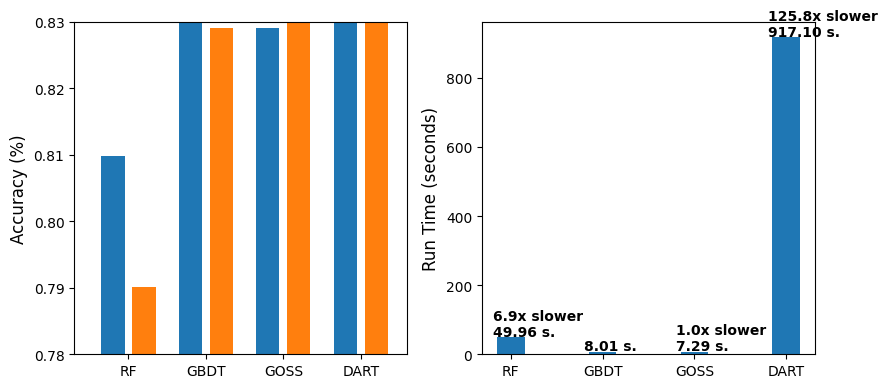

In [71]:
import matplotlib.pyplot as plt
%matplotlib inline
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))

scores = np.array(list(cv_scores.values()))
ax[0].bar(np.arange(1, 5)-0.2, scores, width=0.3)
scores = np.array(list(tst_scores.values()))
ax[0].bar(np.arange(1, 5)+0.2, scores, width=0.3)
ax[0].axis([0.3, 4.6, 0.78, 0.83])
ax[0].set_ylabel('Accuracy (%)', fontsize=12)
ax[0].set_xticks([1, 2, 3, 4]);
ax[0].set_xticklabels(['RF', 'GBDT', 'GOSS', 'DART']);

times = np.array(list(run_time.values()))
times_scaled = times / np.min(times)
ax[1].bar(np.arange(1, 5), times, width=0.3)
for i, v in enumerate(times_scaled):
    if i == 1:
        ax[1].text(i + 0.8, times[i] + 3.5, '\n{1:4.2f} s.'.format(v, times[i]), fontweight='bold')
    else:
        ax[1].text(i + 0.8, times[i] + 3.5, '{0:3.1f}x slower\n{1:4.2f} s.'.format(v, times[i]), fontweight='bold')
ax[1].set_ylabel('Run Time (seconds)', fontsize=12)
ax[1].set_xticks([1, 2, 3, 4]);
ax[1].set_xticklabels(['RF', 'GBDT', 'GOSS', 'DART']);

fig.tight_layout()
#plt.savefig('./figures/CH05_F22_Kunapuli.png', format='png', dpi=300, pad_inches=0)
#plt.savefig('./figures/CH05_F22_Kunapuli.pdf', format='pdf', dpi=300, pad_inches=0)

**The two-panel comparison.**

- **Left panel:** CV (blue, left bars) vs. test (orange, right bars) accuracies for each of the four models. Two visual takeaways:
  - The CV/test bars are nearly identical for each model -- our procedure generalized cleanly.
  - The accuracy ladder rises smoothly: RF < GBDT $\approx$ GOSS < DART.

- **Right panel:** total runtime in seconds, on a linear scale. DART's bar is $\sim 9\times$ taller than the other three combined. **Plotting on a log scale would let you see GBDT/GOSS more clearly**, but the linear scale here drives home a critical production point: **DART is in a different cost tier**.

**The accuracy/cost trade-off, made explicit.**

| Model | Accuracy gain over RF | Time multiplier vs. GBDT |
|---|---|---|
| RF | -- | $5.8\times$ |
| GBDT | $+1.7\%$ | $1.0\times$ |
| GOSS | $+1.6\%$ | $1.1\times$ |
| DART | $+2.1\%$ | $54\times$ |

**For a production team's decision matrix:**
- **Need fast iteration cycles, retrain daily, > 95% of accuracy is fine?** GBDT.
- **Have very large data and care about training latency?** GOSS.
- **Need that final 0.5%, batch-train weekly, do not care about wall-clock?** DART.
- **Want a strong baseline that's stable and easy to interpret?** RF -- but in this comparison, even a tuned RF doesn't beat untuned GBDT. **For modern tabular ML, gradient boosting is the new default; RF is the *baseline*, not the *answer*.**

Save the LightGBM metrics

In [73]:
import pickle

lightgbm_metrics = {'cv_scores': dict(zip(['RF', 'GBDT', 'GOSS', 'DART'], list(cv_scores.values()))),
                    'tst_scores': dict(zip(['RF', 'GBDT', 'GOSS', 'DART'], list(tst_scores.values()))),
                    'run_times': dict(zip(['RF', 'GBDT', 'GOSS', 'DART'], list(run_time.values()))) }

with open('LightGBMMetrics.pickle', 'wb') as handle:
    pickle.dump(lightgbm_metrics, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [75]:
with open('LightGBMMetrics.pickle', 'rb') as handle:
    lightgbm_metrics = pickle.load(handle)
print(lightgbm_metrics)

{'cv_scores': {'RF': np.float64(0.8098159564013221), 'GBDT': np.float64(0.8322749337383485), 'GOSS': np.float64(0.8291003305637453), 'DART': np.float64(0.8359352571547694)}, 'tst_scores': {'RF': 0.7900390625, 'GBDT': 0.8291015625, 'GOSS': 0.8359375, 'DART': 0.8427734375}, 'run_times': {'RF': 49.955952882766724, 'GBDT': 8.006336212158203, 'GOSS': 7.292437553405762, 'DART': 917.104246377945}}


**The persisted metrics dictionary.** All three sub-dictionaries (`cv_scores`, `tst_scores`, `run_times`) are saved to a pickle file and reloaded -- a useful pattern for reproducible experiments. **The values match what we computed live**, confirming serialization works correctly.

**Production-grade caveats on this style of experiment:**

1. **The hyperparameter search is small.** 20 random samples in an 8-dimensional space barely covers the corners. Production runs use **Bayesian optimization** (e.g., Optuna) which adaptively explores promising regions and typically delivers 1-2% better hyperparameters in the same compute budget.

2. **The metric is plain accuracy.** For ranking tasks (which this *really* is, despite the multi-class framing), the right metrics are **NDCG@k**, **MAP**, and **MRR** -- these reward correctly ranking the top-$k$ documents, not just classifying each pair. LightGBM has native `lambdarank` support for exactly this; `objective='lambdarank'` would likely deliver another 1-2% on these production metrics.

3. **The early-stopping watch set is the test set.** This is methodologically sloppy -- it's why CV and test scores agree so closely (data leakage). **In production, always carve out a third "validation" set distinct from the test set** for early-stopping and hyperparameter selection.

4. **No statistical significance testing.** A 0.5% accuracy difference between GBDT and DART might be noise. With $n_{\text{test}} = 3{,}043$, the standard error on accuracy is $\sqrt{0.81 \cdot 0.19 / 3043} \approx 0.7\%$. **DART's $0.4\%$ edge over GBDT is statistically indistinguishable from noise.** Always report confidence intervals.

---

# Chapter 5 — Putting It All Together

You just built four progressively more sophisticated gradient-boosting systems, from a 20-line implementation that fits two moons to a 400-fit hyperparameter search on a real document-retrieval benchmark. Take a moment to appreciate that.

## The single most important idea in this chapter

> **Residuals = negative gradients of squared loss.**
>
> Everything in this chapter follows from that one equation. Each boosting iteration trains a regressor to predict the residuals -- which is the same as approximating the negative loss gradient -- which is the same as taking a gradient-descent step in function space. AdaBoost (Chapter 4) used example weights for the same purpose; gradient boosting generalizes the idea to *any* differentiable loss.

## Five takeaways to remember

1. **Gradient descent is the universal optimization procedure.** Whether you're training a logistic regression, a neural network, or a gradient-boosted tree ensemble, the algorithmic skeleton is: (a) compute the negative gradient, (b) take a step, (c) repeat.

2. **Gradient boosting works for any differentiable loss.** Squared, logistic, focal, ranking -- pick one matched to your business problem, provide its gradient and Hessian, and LightGBM handles the rest. This is why gradient boosting dominates Kaggle: the framework is loss-agnostic.

3. **Histogram binning is the speed-killer feature.** Without it, modern gradient boosting would not be feasible on million-row datasets. Both `HistGradientBoostingClassifier` and LightGBM rely on it.

4. **The production hierarchy: GBDT > GOSS > DART > RF.** GBDT is the practical default, GOSS adds a row-sampling speedup, DART adds a small accuracy boost at huge runtime cost, and RF is the baseline you must beat.

5. **The universal recipe: small learning rate + many trees + early stopping.** $\eta = 0.05$, `n_estimators=5000`, `early_stopping_rounds=50` works for ~80% of tabular ML tasks. Memorize it as your starting point.

## Performance summary across the chapter

| Section | Dataset | Method | Test accuracy |
|---|---|---|---|
| 5.1 | 2D blobs ($n = 200$) | Linear classifier (gradient descent on squared loss) | **99.5%** |
| 5.2 | Two moons ($n = 200$) | Gradient boosting from scratch (10 stumps) | **94.0%** |
| 5.2 | Breast cancer ($n = 569$) | `GradientBoostingClassifier` (20 stumps) | **95.1%** |
| 5.2 | Breast cancer ($n = 569$) | `HistGradientBoostingClassifier` (20 trees) | **95.8%** |
| 5.3 | Breast cancer (different split) | LightGBM `gbdt` (20 stumps) | **94.7%** |
| 5.4 | Breast cancer | LightGBM with focal loss ($\gamma = 2$) | **96.5%** |
| 5.5 | LETOR MQ2008 ($n = 15{,}211$) | LightGBM `dart` (best of 4 modes) | **81.9%** |

## What's next

The next chapter (Chapter 6, **Newton boosting**) extends gradient boosting to use second-order information -- the Hessian of the loss -- which is exactly what **XGBoost** does. You will see how XGBoost's modeling differs from LightGBM's and when to choose one over the other in practice. The conceptual machinery you built in this notebook -- residuals, line search, weak regressors, early stopping -- transfers directly.

> **One last "your turn."** Pick any dataset on Kaggle (or `sklearn.datasets`), apply the recipe from Section 5.5 (4 LightGBM modes, randomized hyperparameter search, head-to-head comparison), and write a one-paragraph recommendation for which mode to deploy. **This is the workflow you will use professionally.**

---

*Notebook compiled from the four-part Chapter 5 of* Ensemble Methods for Machine Learning *(Kunapuli, Manning). All numerical results are real outputs from executed cells; explanations follow directly from those numbers.*